In [ ]:
# SME Credit Scoring and Loan Eligibility System — Prototype Notebook

## Data Disclosure — Read Before Proceeding

#This notebook uses a synthetic dataset. It does not contain any real bank
#statements, GST filings, customer records, or actual loan outcomes.**

### Why synthetic data was used
# A public dataset combining business financials, bank-transaction behaviour,
# GST filing history, digital presence, and local market conditions for Indian
# SMEs does not exist, for concrete reasons:
# - Loan-level default records for Indian SMEs are not published by RBI or
#   individual banks/NBFCs, for confidentiality and regulatory reasons.
# - GST data is public only in **aggregate** form (state-wise / month-wise /
#   national totals via data.gov.in and the GST statistics portal) — never as
#   per-business filing history.
# - Digital-presence and bank-behaviour signals are only meaningful when tied
#   to a real, named business, which this project does not have access to.

# A real, loan-level small-business default dataset **does** exist for the
# US (the SBA "Should This Loan Be Approved or Denied?" dataset), but it has
# none of the alternative-data fields this project needs and is not in an
# Indian/GST context, so it was not used as the primary dataset here.

In [ ]:
# XGBoost and SHAP are not always pre-installed in every Colab runtime,
# so we install them explicitly. Everything else (pandas, numpy, scikit-learn,
# matplotlib, seaborn) comes pre-installed in Colab.
!pip install -q xgboost shap

import xgboost
import shap
print("XGBoost version:", xgboost.__version__)
print("SHAP version:", shap.__version__)

XGBoost version: 3.4.1
SHAP version: 0.52.0


In [ ]:
import os
import numpy as np
import pandas as pd

# Fixed seed so results are reproducible every time you re-run the notebook
RANDOM_STATE = 42
N_SAMPLES = 6000
rng = np.random.default_rng(RANDOM_STATE)

# Mirror the final project's folder structure inside the Colab session,
# so file paths here match the structure we'll zip up later.
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('model', exist_ok=True)

pd.set_option('display.max_columns', 100)

print("Setup complete. Working directory:", os.getcwd())
print("N_SAMPLES:", N_SAMPLES, "| RANDOM_STATE:", RANDOM_STATE)

Setup complete. Working directory: /content
N_SAMPLES: 6000 | RANDOM_STATE: 42


In [ ]:
# Illustrative reference tables. Relative rankings (which sectors/locations are
# riskier or growing faster) are directionally realistic; exact numbers are
# project assumptions for the synthetic generator, not sourced from a specific
# official dataset.
INDUSTRY_TABLE = {
    'Trading & Retail':          {'growth': 6.5,  'risk': 'Medium', 'demand': 65, 'vol': 40},
    'Manufacturing':              {'growth': 7.0,  'risk': 'Medium', 'demand': 60, 'vol': 45},
    'Textiles & Apparel':         {'growth': 5.0,  'risk': 'High',   'demand': 55, 'vol': 55},
    'Food & Beverage':            {'growth': 8.0,  'risk': 'Low',    'demand': 75, 'vol': 30},
    'IT & ITES Services':         {'growth': 12.0, 'risk': 'Low',    'demand': 80, 'vol': 25},
    'Construction & Real Estate': {'growth': 6.0,  'risk': 'High',   'demand': 50, 'vol': 60},
    'Auto Components':            {'growth': 6.5,  'risk': 'Medium', 'demand': 58, 'vol': 42},
    'Healthcare & Pharma':        {'growth': 10.0, 'risk': 'Low',    'demand': 78, 'vol': 28},
    'Agriculture & Allied':       {'growth': 4.5,  'risk': 'High',   'demand': 52, 'vol': 58},
    'Transportation & Logistics': {'growth': 7.5,  'risk': 'Medium', 'demand': 62, 'vol': 38},
}
RISK_NUM = {'Low': 0, 'Medium': 1, 'High': 2}

LOCATION_TABLE = {
    'Urban':      {'unemployment': 6.5, 'inflation': 5.2, 'demand': 75, 'competition': 80, 'growth': 7.0},
    'Semi-Urban': {'unemployment': 7.5, 'inflation': 5.0, 'demand': 60, 'competition': 60, 'growth': 6.0},
    'Rural':      {'unemployment': 8.5, 'inflation': 4.8, 'demand': 45, 'competition': 40, 'growth': 5.0},
}

sectors = list(INDUSTRY_TABLE.keys())
locations = list(LOCATION_TABLE.keys())

print(f"{len(sectors)} industry sectors defined:", sectors)
print(f"{len(locations)} location types defined:", locations)

10 industry sectors defined: ['Trading & Retail', 'Manufacturing', 'Textiles & Apparel', 'Food & Beverage', 'IT & ITES Services', 'Construction & Real Estate', 'Auto Components', 'Healthcare & Pharma', 'Agriculture & Allied', 'Transportation & Logistics']
3 location types defined: ['Urban', 'Semi-Urban', 'Rural']


In [ ]:
n = N_SAMPLES

# --- Business identity ---
industry = rng.choice(sectors, size=n)
location_type = rng.choice(locations, size=n, p=[0.45, 0.35, 0.20])  # more urban/semi-urban than rural
business_age_years = np.clip(rng.gamma(shape=2.0, scale=3.0, size=n), 0.5, 30)

# --- Revenue & growth ---
sector_demand = np.array([INDUSTRY_TABLE[s]['demand'] for s in industry])
base_rev = rng.lognormal(mean=13.6, sigma=1.0, size=n)  # right-skewed: many small, few large SMEs
avg_monthly_revenue = np.clip(base_rev * (0.6 + sector_demand / 100), 50_000, 20_000_000)  # INR

sector_growth_mean = np.array([INDUSTRY_TABLE[s]['growth'] for s in industry])
revenue_growth_rate = rng.normal(sector_growth_mean, 4.5)  # % YoY, sector mean + noise

# --- Expenses & profitability ---
expense_ratio = np.clip(rng.beta(6, 3, size=n), 0.55, 0.97)
avg_monthly_expenses = avg_monthly_revenue * expense_ratio
profit_margin = (avg_monthly_revenue - avg_monthly_expenses) / avg_monthly_revenue * 100

# --- Cash flow behaviour ---
sector_vol = np.array([INDUSTRY_TABLE[s]['vol'] for s in industry]) / 100
cash_flow_volatility = np.clip(rng.gamma(2.0, 0.08, size=n) + sector_vol * 0.3, 0.02, 1.2)
negative_cashflow_months_count = rng.binomial(
    12, np.clip(cash_flow_volatility * 0.35 + (100 - profit_margin) / 400, 0.01, 0.9)
)

buffer_ratio = np.clip(rng.normal(1.5, 0.6, size=n), 0.2, 4.0)
avg_monthly_cash_balance = avg_monthly_expenses * buffer_ratio
min_monthly_balance = np.clip(avg_monthly_cash_balance * (1 - cash_flow_volatility), 0, None)

# --- Existing debt ---
existing_total_liabilities = avg_monthly_revenue * 12 * np.clip(rng.beta(2, 6, size=n), 0, 0.9)
existing_monthly_debt_obligation = existing_total_liabilities / rng.integers(12, 60, size=n)
debt_service_ratio = np.clip(existing_monthly_debt_obligation / avg_monthly_revenue, 0, 2)

working_capital_cycle_days = np.clip(rng.normal(45, 20, size=n), 5, 180)

print("Sample avg_monthly_revenue (INR):", np.round(avg_monthly_revenue[:5], 0))
print("Profit margin range: %.1f%% to %.1f%%" % (profit_margin.min(), profit_margin.max()))
print("Debt-service ratio range: %.2f to %.2f" % (debt_service_ratio.min(), debt_service_ratio.max()))

Sample avg_monthly_revenue (INR): [1475514. 4016430.  597183. 3282141. 8633393.]
Profit margin range: 3.0% to 45.0%
Debt-service ratio range: 0.00 to 0.71


In [ ]:
#Generate Bank Statement Behaviour Features
num_transactions_per_month = np.clip(rng.poisson(20 + np.log1p(avg_monthly_revenue) * 2), 5, 500)
credit_transaction_consistency = np.clip(1 - cash_flow_volatility + rng.normal(0, 0.1, size=n), 0, 1)
cash_deposit_frequency = np.clip(rng.poisson(4, size=n), 0, 30)
bounced_payment_count = rng.poisson(np.clip(debt_service_ratio * 2 + cash_flow_volatility * 1.5, 0, 8))
bank_balance_volatility = np.clip(cash_flow_volatility * rng.normal(1, 0.15, size=n), 0.01, 1.5)
recurring_revenue_ratio = np.clip(
    rng.beta(3, 3, size=n) + np.where(np.isin(industry, ['IT & ITES Services', 'Healthcare & Pharma']), 0.15, 0),
    0, 1
)

print("Avg transactions/month range:", num_transactions_per_month.min(), "-", num_transactions_per_month.max())
print("Bounced payment count — mean: %.2f, max: %d" % (bounced_payment_count.mean(), bounced_payment_count.max()))

Avg transactions/month range: 25 - 83
Bounced payment count — mean: 0.64, max: 6


In [ ]:
#Generate GST Proxy Features
gst_filing_regularity_score = np.clip(
    rng.beta(6, 2, size=n) - (business_age_years < 1).astype(float) * 0.1, 0, 1
)
gst_late_filings_count = rng.poisson(np.clip((1 - gst_filing_regularity_score) * 6, 0, 12))
gst_turnover_growth = revenue_growth_rate + rng.normal(0, 2.5, size=n)  # tracks revenue growth loosely
gst_turnover_consistency = np.clip(1 - cash_flow_volatility + rng.normal(0, 0.08, size=n), 0, 1)
gst_filing_gap_max_days = np.clip(gst_late_filings_count * 9 + rng.normal(0, 5, size=n), 0, 120)

print("GST filing regularity score — mean: %.2f" % gst_filing_regularity_score.mean())
print("GST late filings — mean: %.2f, max: %d" % (gst_late_filings_count.mean(), gst_late_filings_count.max()))

GST filing regularity score — mean: 0.75
GST late filings — mean: 1.54, max: 10


In [ ]:
# --- Digital presence (synthetic proxy) ---
urban_bonus = (location_type == 'Urban').astype(float) * 0.15
it_bonus = np.isin(industry, ['IT & ITES Services', 'Healthcare & Pharma']).astype(float) * 0.2

has_website = rng.random(n) < np.clip(0.45 + urban_bonus + it_bonus, 0, 0.95)
has_google_listing = rng.random(n) < np.clip(0.55 + urban_bonus, 0, 0.95)
has_social_media = rng.random(n) < np.clip(0.50 + urban_bonus, 0, 0.95)
num_active_digital_channels = has_website.astype(int) + has_google_listing.astype(int) + has_social_media.astype(int)
online_review_count = rng.poisson(np.clip(num_active_digital_channels * 8 + business_age_years, 0, 300))
online_review_rating = np.clip(rng.normal(4.0, 0.5, size=n), 1, 5)
digital_engagement_score = np.clip(
    num_active_digital_channels / 3 * 50 + np.clip(online_review_count, 0, 100) / 100 * 30 + online_review_rating / 5 * 20,
    0, 100
)

# --- Industry-level features ---
industry_growth_rate = np.array([INDUSTRY_TABLE[s]['growth'] for s in industry]) + rng.normal(0, 1.0, size=n)
industry_risk_level = np.array([INDUSTRY_TABLE[s]['risk'] for s in industry])
industry_risk_numeric = np.array([RISK_NUM[r] for r in industry_risk_level])
sector_demand_score = np.array([INDUSTRY_TABLE[s]['demand'] for s in industry]) + rng.normal(0, 3, size=n)
sector_volatility_score = np.array([INDUSTRY_TABLE[s]['vol'] for s in industry]) + rng.normal(0, 3, size=n)

# --- Local market features ---
loc_unemployment = np.array([LOCATION_TABLE[l]['unemployment'] for l in location_type])
loc_inflation = np.array([LOCATION_TABLE[l]['inflation'] for l in location_type])
loc_demand = np.array([LOCATION_TABLE[l]['demand'] for l in location_type])
loc_competition = np.array([LOCATION_TABLE[l]['competition'] for l in location_type])
loc_growth = np.array([LOCATION_TABLE[l]['growth'] for l in location_type])

local_unemployment_rate = np.clip(rng.normal(loc_unemployment, 1.0), 2, 15)
local_inflation_rate = np.clip(rng.normal(loc_inflation, 0.6), 2, 10)
local_demand_index = np.clip(rng.normal(loc_demand, 8), 10, 100)
market_competition_score = np.clip(rng.normal(loc_competition, 10), 5, 100)
regional_business_growth_rate = np.clip(rng.normal(loc_growth, 1.5), -2, 15)

print("Businesses with a website:", has_website.sum(), f"({has_website.mean()*100:.1f}%)")
print("Digital engagement score range: %.1f to %.1f" % (digital_engagement_score.min(), digital_engagement_score.max()))
print("Local unemployment rate range: %.1f%% to %.1f%%" % (local_unemployment_rate.min(), local_unemployment_rate.max()))

Businesses with a website: 3386 (56.4%)
Digital engagement score range: 11.2 to 88.9
Local unemployment rate range: 2.9% to 11.3%


In [ ]:
#Assemble the Full Synthetic Dataset
df = pd.DataFrame({
    'business_id': [f'SME_{i:05d}' for i in range(n)],
    'industry_sector': industry,
    'location_type': location_type,
    'business_age_years': business_age_years,
    'avg_monthly_revenue': avg_monthly_revenue,
    'revenue_growth_rate': revenue_growth_rate,
    'avg_monthly_expenses': avg_monthly_expenses,
    'profit_margin': profit_margin,
    'cash_flow_volatility': cash_flow_volatility,
    'negative_cashflow_months_count': negative_cashflow_months_count,
    'avg_monthly_cash_balance': avg_monthly_cash_balance,
    'min_monthly_balance': min_monthly_balance,
    'existing_total_liabilities': existing_total_liabilities,
    'existing_monthly_debt_obligation': existing_monthly_debt_obligation,
    'debt_service_ratio': debt_service_ratio,
    'working_capital_cycle_days': working_capital_cycle_days,
    'num_transactions_per_month': num_transactions_per_month,
    'credit_transaction_consistency': credit_transaction_consistency,
    'cash_deposit_frequency': cash_deposit_frequency,
    'bounced_payment_count': bounced_payment_count,
    'bank_balance_volatility': bank_balance_volatility,
    'recurring_revenue_ratio': recurring_revenue_ratio,
    'gst_filing_regularity_score': gst_filing_regularity_score,
    'gst_late_filings_count': gst_late_filings_count,
    'gst_turnover_growth': gst_turnover_growth,
    'gst_turnover_consistency': gst_turnover_consistency,
    'gst_filing_gap_max_days': gst_filing_gap_max_days,
    'has_website': has_website.astype(int),
    'has_google_listing': has_google_listing.astype(int),
    'has_social_media': has_social_media.astype(int),
    'num_active_digital_channels': num_active_digital_channels,
    'online_review_count': online_review_count,
    'online_review_rating': online_review_rating,
    'digital_engagement_score': digital_engagement_score,
    'industry_growth_rate': industry_growth_rate,
    'industry_risk_level': industry_risk_level,
    'sector_demand_score': sector_demand_score,
    'sector_volatility_score': sector_volatility_score,
    'local_unemployment_rate': local_unemployment_rate,
    'local_inflation_rate': local_inflation_rate,
    'local_demand_index': local_demand_index,
    'market_competition_score': market_competition_score,
    'regional_business_growth_rate': regional_business_growth_rate,
})

print("Assembled dataframe shape:", df.shape)
print("Missing values total:", df.isna().sum().sum())

Assembled dataframe shape: (6000, 43)
Missing values total: 0


In [ ]:
#Generate the Target Variable (Default Label)
def z(x):
    """Standardize a feature to mean 0, std 1, for combining features on a common scale."""
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std() + 1e-9)

# Weighted combination of risk drivers. Positive weight = increases default risk,
# negative weight = protective factor. Weights are project assumptions reflecting
# commonly cited underwriting logic, not fitted from real data.
risk_z = (
      0.9 * z(df['debt_service_ratio'])
    + 0.8 * z(df['cash_flow_volatility'])
    + 0.6 * z(df['negative_cashflow_months_count'])
    + 0.7 * z(df['bounced_payment_count'])
    - 0.5 * z(df['revenue_growth_rate'])
    - 0.6 * z(df['gst_filing_regularity_score'])
    + 0.5 * z(df['gst_late_filings_count'])
    - 0.4 * z(df['business_age_years'])
    - 0.3 * z(df['digital_engagement_score'])
    + 0.3 * z(industry_risk_numeric)
    + 0.2 * z(df['local_unemployment_rate'])
    - 0.3 * z(df['recurring_revenue_ratio'])
    + rng.normal(0, 2.5, size=n)   # unobserved real-world noise — keeps the problem realistically hard
)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Calibrate the bias term so the overall base default rate matches our target,
# which we set slightly above the current national MSME NPA ratio (~3-4%) because
# this simulated portfolio deliberately skews toward newer, thinner-file SMEs.
TARGET_BASE_RATE = 0.14
a = 1.1
lo, hi = -8, 8
for _ in range(60):
    mid = (lo + hi) / 2
    rate = sigmoid(a * risk_z + mid).mean()
    if rate > TARGET_BASE_RATE:
        hi = mid
    else:
        lo = mid
b = (lo + hi) / 2

default_probability_true = sigmoid(a * risk_z + b)
df['default_label'] = rng.binomial(1, default_probability_true)

print("Calibrated bias term (b):", round(b, 3))
print("Achieved base default rate: %.2f%%" % (df['default_label'].mean() * 100))
print("\nDirectional sanity check (correlation with default_label):")
for col in ['debt_service_ratio', 'cash_flow_volatility', 'bounced_payment_count',
            'gst_filing_regularity_score', 'business_age_years', 'digital_engagement_score']:
    print(f"  {col:32s}: {df[col].corr(df['default_label']):+.3f}")

Calibrated bias term (b): -4.517
Achieved base default rate: 14.07%

Directional sanity check (correlation with default_label):
  debt_service_ratio              : +0.218
  cash_flow_volatility            : +0.273
  bounced_payment_count           : +0.201
  gst_filing_regularity_score     : -0.168
  business_age_years              : -0.077
  digital_engagement_score        : -0.054


In [ ]:
#Save Raw Dataset & Inspect Output
output_path = 'data/raw/sme_credit_data_raw.csv'
df.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nColumn data types:")
print(df.dtypes.value_counts())
print("\nTarget distribution:")
print(df['default_label'].value_counts())
print(df['default_label'].value_counts(normalize=True).round(4))

Saved to: data/raw/sme_credit_data_raw.csv

Dataset shape: (6000, 44)

First 5 rows:


,business_id,industry_sector,location_type,business_age_years,avg_monthly_revenue,revenue_growth_rate,avg_monthly_expenses,profit_margin,cash_flow_volatility,negative_cashflow_months_count,avg_monthly_cash_balance,min_monthly_balance,existing_total_liabilities,existing_monthly_debt_obligation,debt_service_ratio,working_capital_cycle_days,num_transactions_per_month,credit_transaction_consistency,cash_deposit_frequency,bounced_payment_count,bank_balance_volatility,recurring_revenue_ratio,gst_filing_regularity_score,gst_late_filings_count,gst_turnover_growth,gst_turnover_consistency,gst_filing_gap_max_days,has_website,has_google_listing,has_social_media,num_active_digital_channels,online_review_count,online_review_rating,digital_engagement_score,industry_growth_rate,industry_risk_level,sector_demand_score,sector_volatility_score,local_unemployment_rate,local_inflation_rate,local_demand_index,market_competition_score,regional_business_growth_rate,default_label
0,SME_00000,Trading & Retail,Rural,1.056578,1.475514e+06,8.569749,1.231817e+06,16.516083,0.258362,3,1.902061e+06,1.410640e+06,5.720768e+06,1.121719e+05,0.076022,41.367603,54,0.575125,3,0,0.203215,0.399250,0.817254,1,5.407377,0.794840,4.796660,0,1,0,1,15,3.523455,35.260486,7.629902,Medium,64.487924,37.844035,7.699964,3.926630,40.412840,39.778217,4.341432,0
1,SME_00001,Healthcare & Pharma,Semi-Urban,10.038082,4.016430e+06,22.367747,2.649003e+06,34.045823,0.124847,2,4.707377e+06,4.119675e+06,1.261557e+07,3.319886e+05,0.082658,59.825357,38,0.756665,4,0,0.102650,0.691140,0.614874,3,22.508126,0.883955,23.356188,1,0,1,2,33,3.949957,59.033163,9.792352,Low,79.612754,24.739856,7.098296,5.139171,60.462293,67.581842,3.780784,0
2,SME_00002,Auto Components,Urban,5.671265,5.971826e+05,6.521316,4.063549e+05,31.954653,0.204276,3,7.039576e+05,5.601556e+05,2.586520e+06,4.880227e+04,0.081721,81.237930,42,0.654089,8,0,0.239963,0.127783,0.921893,1,5.969544,0.733627,10.549833,0,0,1,1,14,4.787793,40.017837,5.679672,Medium,62.015475,38.633787,6.033885,5.078944,79.218402,82.449934,8.532112,0
3,SME_00003,IT & ITES Services,Semi-Urban,11.311724,3.282141e+06,14.106896,2.788951e+06,15.026464,0.501050,5,3.654621e+06,1.823472e+06,1.269514e+07,2.821142e+05,0.085954,21.380358,54,0.594365,5,0,0.438245,0.588932,0.688316,3,15.620729,0.559181,27.957289,0,1,1,2,30,3.659326,56.970636,12.907323,Low,80.704546,23.267502,7.717213,6.455719,55.658915,62.403142,8.865026,0
4,SME_00004,IT & ITES Services,Urban,6.985467,8.633393e+06,6.431918,6.062298e+06,29.780819,0.387813,0,1.062728e+07,6.505885e+06,3.472952e+07,2.894126e+06,0.335225,50.794254,42,0.496246,3,1,0.436389,0.540625,0.651711,2,4.868787,0.579085,23.847136,0,1,1,2,19,3.259589,52.071691,10.084137,Low,77.620046,25.542968,7.444843,5.779325,75.592306,80.878703,6.517521,0



Column data types:
float64    29
int64      11
object      4
Name: count, dtype: int64

Target distribution:
default_label
0    5156
1     844
Name: count, dtype: int64
default_label
0    0.8593
1    0.1407
Name: proportion, dtype: float64


In [ ]:
#Load the Raw Dataset
import pandas as pd
import numpy as np

df = pd.read_csv('data/raw/sme_credit_data_raw.csv')
print("Loaded shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)

Loaded shape: (6000, 44)

Column dtypes:
business_id                          object
industry_sector                      object
location_type                        object
business_age_years                  float64
avg_monthly_revenue                 float64
revenue_growth_rate                 float64
avg_monthly_expenses                float64
profit_margin                       float64
cash_flow_volatility                float64
negative_cashflow_months_count        int64
avg_monthly_cash_balance            float64
min_monthly_balance                 float64
existing_total_liabilities          float64
existing_monthly_debt_obligation    float64
debt_service_ratio                  float64
working_capital_cycle_days          float64
num_transactions_per_month            int64
credit_transaction_consistency      float64
cash_deposit_frequency                int64
bounced_payment_count                 int64
bank_balance_volatility             float64
recurring_revenue_ratio            

In [ ]:
#Missing Value Analysis
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False)

print("Total missing values in dataset:", df.isna().sum().sum())
if len(missing_report) == 0:
    print("No missing values found in any column.")
else:
    display(missing_report)

Total missing values in dataset: 0
No missing values found in any column.


In [ ]:
#Duplicate Analysis
exact_duplicates = df.duplicated().sum()
id_duplicates = df['business_id'].duplicated().sum()

# Also check duplicates ignoring the identifier column, since two DIFFERENT
# businesses could legitimately share similar-but-not-identical feature values
duplicates_ignoring_id = df.drop(columns=['business_id']).duplicated().sum()

print("Exact duplicate rows (including business_id):", exact_duplicates)
print("Duplicate business_id values:", id_duplicates)
print("Duplicate rows ignoring business_id:", duplicates_ignoring_id)

Exact duplicate rows (including business_id): 0
Duplicate business_id values: 0
Duplicate rows ignoring business_id: 0


In [ ]:
print("Descriptive statistics (numeric columns):")
display(df.describe().T)

# Domain sanity checks — each should print "OK". A real dataset could fail any of these.
checks = {
    "Revenue is non-negative": (df['avg_monthly_revenue'] >= 0).all(),
    "Expenses are non-negative": (df['avg_monthly_expenses'] >= 0).all(),
    "Business age within 0-40 years": df['business_age_years'].between(0, 40).all(),
    "Debt-service ratio within 0-3": df['debt_service_ratio'].between(0, 3).all(),
    "GST filing regularity within 0-1": df['gst_filing_regularity_score'].between(0, 1).all(),
    "Review rating within 1-5": df['online_review_rating'].between(1, 5).all(),
    "Default label is binary": df['default_label'].isin([0, 1]).all(),
}
print("\nDomain sanity checks:")
for check_name, passed in checks.items():
    print(f"  [{'OK' if passed else 'FAIL'}] {check_name}")

Descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
business_age_years,6000.0,6.064793e+00,4.326321e+00,0.500000,2.885509e+00,5.036120e+00,8.111228e+00,3.000000e+01
avg_monthly_revenue,6000.0,1.678063e+06,2.070846e+06,50000.000000,5.242292e+05,1.033449e+06,1.980810e+06,2.000000e+07
revenue_growth_rate,6000.0,7.364720e+00,5.048244e+00,-14.656542,3.912105e+00,7.316334e+00,1.074406e+01,2.599962e+01
avg_monthly_expenses,6000.0,1.155386e+06,1.458704e+06,27500.000000,3.509279e+05,6.925620e+05,1.352918e+06,1.496111e+07
profit_margin,6000.0,3.138114e+01,1.151336e+01,3.000000,2.250391e+01,3.227659e+01,4.340057e+01,4.500000e+01
cash_flow_volatility,6000.0,2.867894e-01,1.211125e-01,0.081322,2.012495e-01,2.644971e-01,3.473474e-01,1.200000e+00
negative_cashflow_months_count,6000.0,3.279500e+00,1.651818e+00,0.000000,2.000000e+00,3.000000e+00,4.000000e+00,1.100000e+01
avg_monthly_cash_balance,6000.0,1.731171e+06,2.427178e+06,13621.360907,4.402857e+05,9.731494e+05,2.027211e+06,3.540006e+07
min_monthly_balance,6000.0,1.240560e+06,1.782817e+06,0.000000,3.062346e+05,6.743824e+05,1.433361e+06,2.780757e+07
existing_total_liabilities,6000.0,5.083697e+06,7.798148e+06,14495.445185,1.142315e+06,2.588712e+06,5.841907e+06,1.310351e+08



Domain sanity checks:
  [OK] Revenue is non-negative
  [OK] Expenses are non-negative
  [OK] Business age within 0-40 years
  [OK] Debt-service ratio within 0-3
  [OK] GST filing regularity within 0-1
  [OK] Review rating within 1-5
  [OK] Default label is binary


In [ ]:
# Explicit integer casts for count/flag columns (guards against float re-inference on reload)
int_columns = [
    'negative_cashflow_months_count', 'num_transactions_per_month', 'cash_deposit_frequency',
    'bounced_payment_count', 'has_website', 'has_google_listing', 'has_social_media',
    'num_active_digital_channels', 'online_review_count', 'gst_late_filings_count', 'default_label'
]
df[int_columns] = df[int_columns].astype(int)

# Categorical dtype for the three grouping columns
categorical_columns = ['industry_sector', 'location_type', 'industry_risk_level']
df[categorical_columns] = df[categorical_columns].astype('category')

print("Updated dtypes:")
print(df.dtypes.value_counts())
print("\nCategory levels:")
for col in categorical_columns:
    print(f"  {col}: {list(df[col].cat.categories)}")

Updated dtypes:
float64     29
int64       11
category     1
object       1
category     1
category     1
Name: count, dtype: int64

Category levels:
  industry_sector: ['Agriculture & Allied', 'Auto Components', 'Construction & Real Estate', 'Food & Beverage', 'Healthcare & Pharma', 'IT & ITES Services', 'Manufacturing', 'Textiles & Apparel', 'Trading & Retail', 'Transportation & Logistics']
  location_type: ['Rural', 'Semi-Urban', 'Urban']
  industry_risk_level: ['High', 'Low', 'Medium']


In [ ]:
#Leakage & Fairness Review
leakage_fairness_notes = """
LEAKAGE REVIEW
---------------
All 43 feature columns represent information a lender could reasonably observe
BEFORE approving or rejecting the loan application:
  - Financial/bank-behaviour features come from historical statements
    (typically the trailing 6-12 months), which precede the decision.
  - GST features reflect historical filing behaviour up to the application date.
  - Digital presence, industry, and local market features are observable
    independent of the loan decision itself.
None of the features encode information that would only exist AFTER
disbursement (e.g., post-loan repayment history, days-past-due after the
loan started, collections status) — including any such field would be
target leakage and was deliberately excluded from the schema.

FAIRNESS REVIEW
----------------
No sensitive personal characteristics are present in this dataset:
  - No caste, religion, gender, or name-based fields.
  - No individual owner's personal credit data.
  - 'location_type' (Urban/Semi-Urban/Rural) is a business-operations
    variable, not a proxy for a protected personal characteristic, but it
    IS worth monitoring in Explainable AI for disparate impact,
    since rural businesses may systematically score lower and that
    pattern deserves scrutiny, not blind trust.
  - 'business_id' and 'industry_sector'/'location_type' text labels are
    excluded from the MODEL FEATURES in (identifiers aren't
    predictive; raw category text needs encoding first) — this is a
    feature-selection decision, not a fairness fix by itself.

HIGH-CORRELATION WATCHLIST (to revisit numerically in Phase 4 EDA)
--------------------------------------------------------------------
  - cash_flow_volatility vs. bank_balance_volatility (both derived from
    similar underlying volatility signal — likely redundant)
  - gst_turnover_growth vs. revenue_growth_rate (GST turnover was
    deliberately built to track revenue growth)
  - avg_monthly_revenue vs. avg_monthly_expenses (expenses were built as
    a ratio of revenue)
These will be checked with an actual correlation matrix next phase, and
one of each highly correlated pair may be dropped in Feature Selection
to reduce redundancy.
"""
print(leakage_fairness_notes)


LEAKAGE REVIEW
---------------
All 43 feature columns represent information a lender could reasonably observe
BEFORE approving or rejecting the loan application:
  - Financial/bank-behaviour features come from historical statements
    (typically the trailing 6-12 months), which precede the decision.
  - GST features reflect historical filing behaviour up to the application date.
  - Digital presence, industry, and local market features are observable
    independent of the loan decision itself.
None of the features encode information that would only exist AFTER
disbursement (e.g., post-loan repayment history, days-past-due after the
loan started, collections status) — including any such field would be
target leakage and was deliberately excluded from the schema.

FAIRNESS REVIEW
----------------
No sensitive personal characteristics are present in this dataset:
  - No caste, religion, gender, or name-based fields.
  - No individual owner's personal credit data.
  - 'location_type' (U

In [ ]:
#Save Cleaned Dataset
processed_path = 'data/processed/sme_credit_data_cleaned.csv'
df.to_csv(processed_path, index=False)

print("Cleaned dataset saved to:", processed_path)
print("Final shape:", df.shape)
print("\nDataset is ready for EDA.")

Cleaned dataset saved to: data/processed/sme_credit_data_cleaned.csv
Final shape: (6000, 44)

Dataset is ready for EDA.


In [ ]:
#Load Cleaned Data & EDA Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/processed/sme_credit_data_cleaned.csv')
df['industry_sector'] = df['industry_sector'].astype('category')
df['location_type'] = df['location_type'].astype('category')
df['industry_risk_level'] = df['industry_risk_level'].astype('category')

sns.set_style('whitegrid')
print("Dataset ready for EDA. Shape:", df.shape)

Dataset ready for EDA. Shape: (6000, 44)


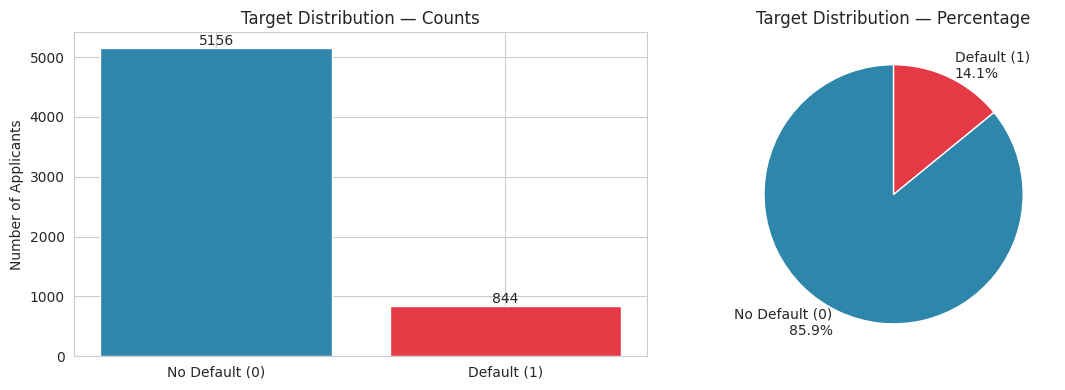

Default rate: 14.07%


In [ ]:
#Target Distribution (Class Balance)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['default_label'].value_counts().sort_index()
labels = ['No Default (0)', 'Default (1)']
axes[0].bar(labels, counts.values, color=['#2E86AB', '#E63946'])
axes[0].set_title('Target Distribution — Counts')
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center')

pct = (counts / counts.sum() * 100).round(1)
axes[1].pie(pct.values, labels=[f'{l}\n{p}%' for l, p in zip(labels, pct.values)],
            colors=['#2E86AB', '#E63946'], startangle=90)
axes[1].set_title('Target Distribution — Percentage')

plt.tight_layout()
plt.show()

print("Default rate: %.2f%%" % (df['default_label'].mean() * 100))

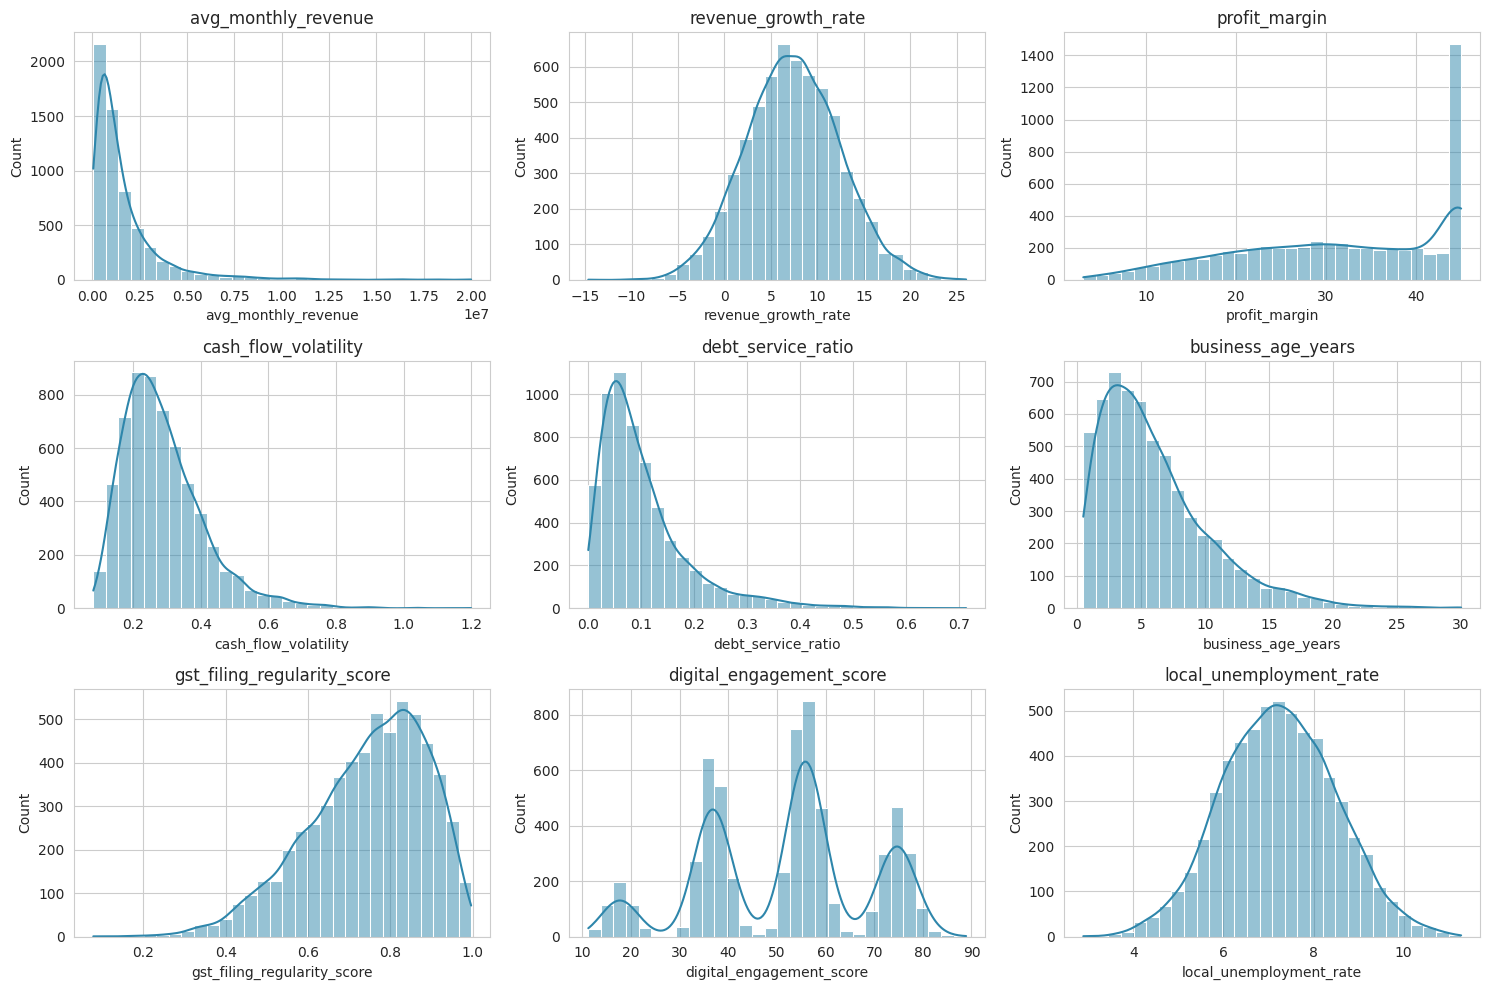

In [ ]:
#Numeric Feature Distributions
key_features = [
    'avg_monthly_revenue', 'revenue_growth_rate', 'profit_margin', 'cash_flow_volatility',
    'debt_service_ratio', 'business_age_years', 'gst_filing_regularity_score',
    'digital_engagement_score', 'local_unemployment_rate'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), key_features):
    sns.histplot(df[col], bins=30, ax=ax, color='#2E86AB', kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

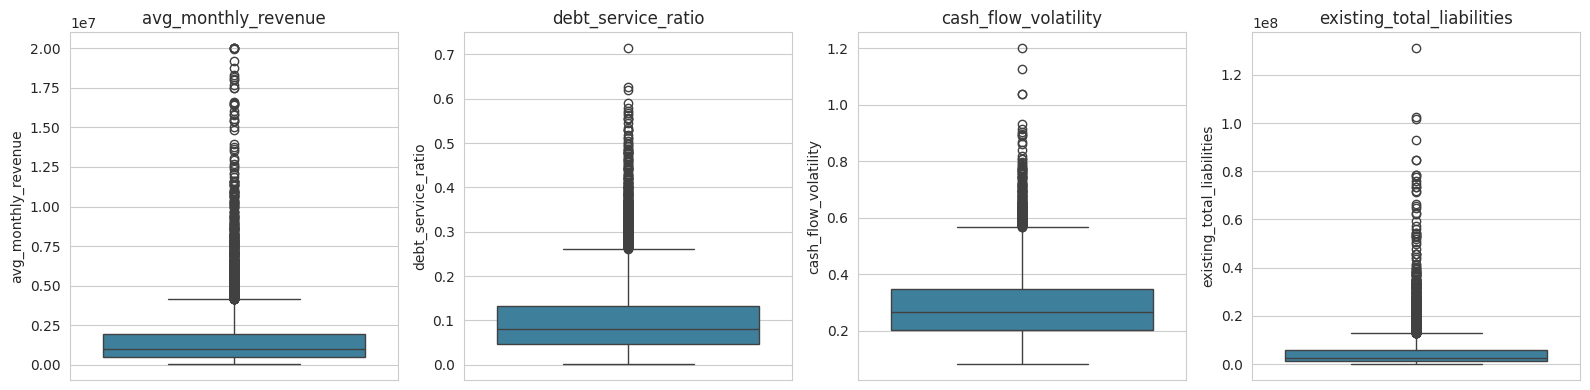

In [ ]:
# Boxplots: Key Financial Features
box_features = ['avg_monthly_revenue', 'debt_service_ratio', 'cash_flow_volatility', 'existing_total_liabilities']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, box_features):
    sns.boxplot(y=df[col], ax=ax, color='#2E86AB')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
# Outlier Analysis (IQR Method)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['default_label'])

outlier_counts = {}
for col in numeric_df.columns:
    q1, q3 = numeric_df[col].quantile(0.25), numeric_df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum())

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print("Top 10 columns by IQR-flagged outlier count:")
print(outlier_series.head(10))
print(f"\nMax outlier share: {outlier_series.max() / len(df) * 100:.1f}% of records")

Top 10 columns by IQR-flagged outlier count:
existing_monthly_debt_obligation    563
existing_total_liabilities          532
min_monthly_balance                 526
avg_monthly_cash_balance            494
avg_monthly_expenses                492
avg_monthly_revenue                 482
debt_service_ratio                  354
business_age_years                  222
bank_balance_volatility             209
bounced_payment_count               202
dtype: int64

Max outlier share: 9.4% of records


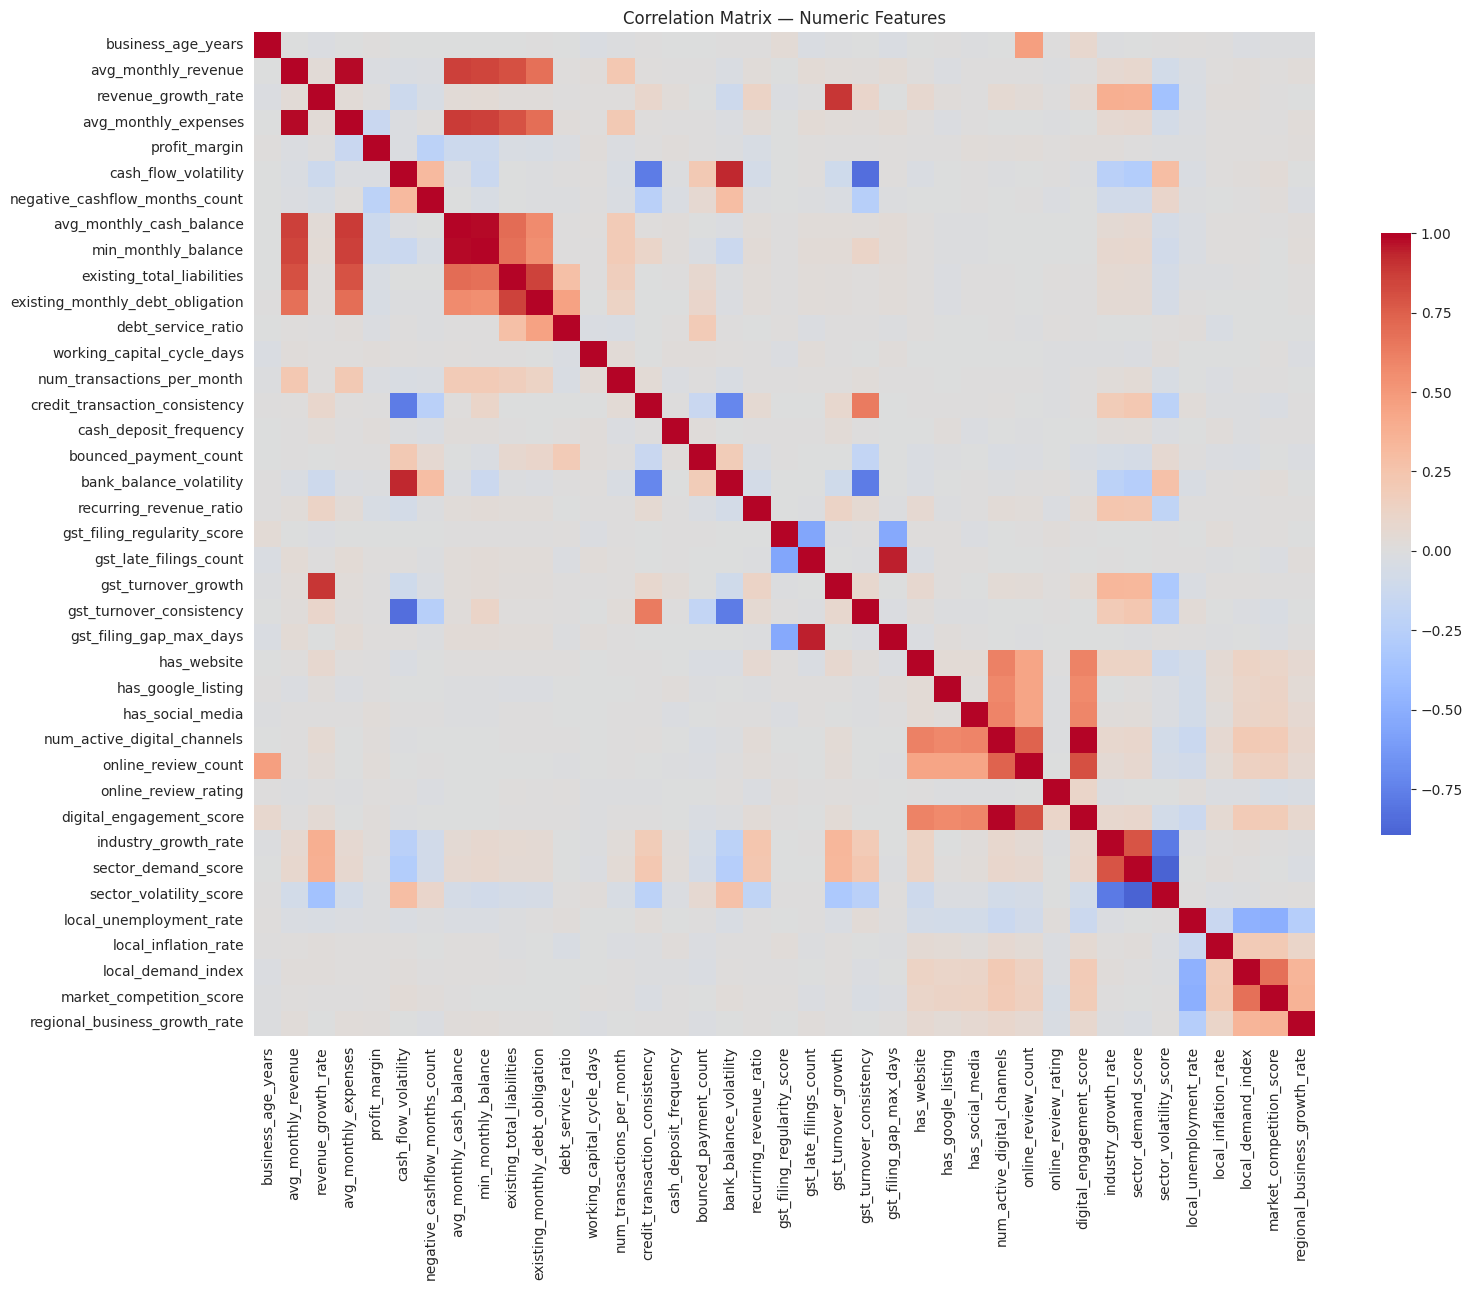


20 feature pairs with |correlation| > 0.75:
  ('num_active_digital_channels', 'digital_engagement_score', 0.987)
  ('avg_monthly_cash_balance', 'min_monthly_balance', 0.98)
  ('avg_monthly_revenue', 'avg_monthly_expenses', 0.978)
  ('gst_late_filings_count', 'gst_filing_gap_max_days', 0.945)
  ('cash_flow_volatility', 'bank_balance_volatility', 0.933)
  ('sector_demand_score', 'sector_volatility_score', -0.896)
  ('revenue_growth_rate', 'gst_turnover_growth', 0.895)
  ('avg_monthly_expenses', 'avg_monthly_cash_balance', 0.878)
  ('avg_monthly_expenses', 'min_monthly_balance', 0.866)
  ('avg_monthly_revenue', 'avg_monthly_cash_balance', 0.861)
  ('existing_total_liabilities', 'existing_monthly_debt_obligation', 0.859)
  ('avg_monthly_revenue', 'min_monthly_balance', 0.849)
  ('cash_flow_volatility', 'gst_turnover_consistency', -0.834)
  ('avg_monthly_revenue', 'existing_total_liabilities', 0.806)
  ('online_review_count', 'digital_engagement_score', 0.805)
  ('avg_monthly_expenses', 'e

In [ ]:
# Correlation Matrix (Heatmap)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.6})
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

# Flag pairs that are highly redundant
high_corr_pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr.iloc[i, j]
        if abs(v) > 0.75:
            high_corr_pairs.append((cols[i], cols[j], round(float(v), 3)))
high_corr_pairs.sort(key=lambda x: -abs(x[2]))

print(f"\n{len(high_corr_pairs)} feature pairs with |correlation| > 0.75:")
for pair in high_corr_pairs:
    print(" ", pair)

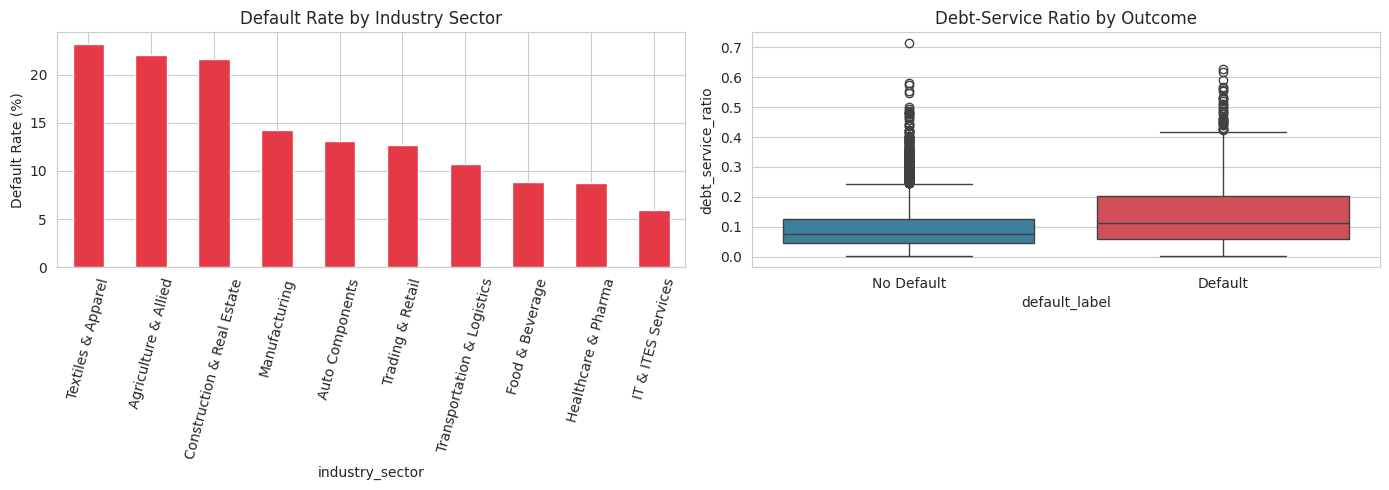

Default rate by industry sector (%):
industry_sector
Textiles & Apparel            23.26
Agriculture & Allied          22.09
Construction & Real Estate    21.61
Manufacturing                 14.26
Auto Components               13.11
Trading & Retail              12.67
Transportation & Logistics    10.71
Food & Beverage                8.83
Healthcare & Pharma            8.71
IT & ITES Services             5.96
Name: default_label, dtype: float64

Default rate by location type (%):
location_type
Rural         15.09
Semi-Urban    14.69
Urban         13.16
Name: default_label, dtype: float64


In [ ]:
# Feature Relationships with the Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

default_by_industry = (
    df.groupby('industry_sector', observed=True)['default_label'].mean() * 100
).sort_values(ascending=False)
default_by_industry.plot(kind='bar', ax=axes[0], color='#E63946')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Industry Sector')
axes[0].tick_params(axis='x', rotation=75)

sns.boxplot(data=df, x='default_label', y='debt_service_ratio', hue='default_label',
            palette=['#2E86AB', '#E63946'], legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Default', 'Default'])
axes[1].set_title('Debt-Service Ratio by Outcome')

plt.tight_layout()
plt.show()

print("Default rate by industry sector (%):")
print(default_by_industry.round(2))
print("\nDefault rate by location type (%):")
print((df.groupby('location_type', observed=True)['default_label'].mean() * 100).round(2).sort_values(ascending=False))

In [ ]:
# Feature Engineering: New Ratio Features
# Cash runway: how many months of expenses the average cash balance could cover
df['cash_buffer_months'] = df['avg_monthly_cash_balance'] / df['avg_monthly_expenses']

# What's actually left over each month after expenses AND existing debt payments
df['net_monthly_cashflow'] = df['avg_monthly_revenue'] - df['avg_monthly_expenses'] - df['existing_monthly_debt_obligation']

# That leftover amount as a share of revenue (comparable across business sizes)
df['free_cash_flow_ratio'] = df['net_monthly_cashflow'] / df['avg_monthly_revenue']

# Overall leverage: total existing debt relative to annual revenue
df['liabilities_to_annual_revenue'] = df['existing_total_liabilities'] / (df['avg_monthly_revenue'] * 12)

new_cols = ['cash_buffer_months', 'net_monthly_cashflow', 'free_cash_flow_ratio', 'liabilities_to_annual_revenue']
print(df[new_cols].describe().T[['mean', 'min', 'max']].round(3))
print("\nAny inf/NaN introduced?", np.isinf(df[new_cols]).sum().sum() + df[new_cols].isna().sum().sum())
print("\nCorrelation with default_label:")
for c in new_cols:
    print(f"  {c:32s}: {df[c].corr(df['default_label']):+.3f}")

                                     mean          min          max
cash_buffer_months                  1.499        0.200        3.738
net_monthly_cashflow           346874.240 -5163661.226  6908836.311
free_cash_flow_ratio                0.210       -0.501        0.448
liabilities_to_annual_revenue       0.252        0.003        0.871

Any inf/NaN introduced? 0

Correlation with default_label:
  cash_buffer_months              : +0.003
  net_monthly_cashflow            : -0.064
  free_cash_flow_ratio            : -0.131
  liabilities_to_annual_revenue   : +0.150


In [ ]:
# Encode Categorical Variables
RISK_NUM = {'Low': 0, 'Medium': 1, 'High': 2}
df['industry_risk_numeric'] = df['industry_risk_level'].map(RISK_NUM)

df_encoded = pd.get_dummies(df, columns=['industry_sector', 'location_type'], drop_first=True)

onehot_cols = [c for c in df_encoded.columns if c.startswith('industry_sector_') or c.startswith('location_type_')]
print(f"Created {len(onehot_cols)} one-hot columns:")
print(onehot_cols)
print("\nEncoded dataframe shape:", df_encoded.shape)

Created 11 one-hot columns:
['industry_sector_Auto Components', 'industry_sector_Construction & Real Estate', 'industry_sector_Food & Beverage', 'industry_sector_Healthcare & Pharma', 'industry_sector_IT & ITES Services', 'industry_sector_Manufacturing', 'industry_sector_Textiles & Apparel', 'industry_sector_Trading & Retail', 'industry_sector_Transportation & Logistics', 'location_type_Semi-Urban', 'location_type_Urban']

Encoded dataframe shape: (6000, 58)


In [ ]:
# Columns excluded from the MODEL (kept in the dataframe for other uses):
#   - num_active_digital_channels, digital_engagement_score: composites of has_website/
#     has_google_listing/has_social_media/online_review_count/online_review_rating, which
#     we keep individually instead (more interpretable for SHAP explanations)
#   - avg_monthly_cash_balance: redundant with min_monthly_balance (r=0.98); the more
#     conservative min-balance figure is more risk-relevant and is kept
#   - avg_monthly_expenses: redundant given profit_margin + avg_monthly_revenue already
#     capture the revenue-expense relationship (r=0.978); kept in the dataframe for the
#     Loan Optimizer
#   - gst_filing_gap_max_days: redundant with gst_late_filings_count (r=0.945)
#   - bank_balance_volatility: redundant with cash_flow_volatility (r=0.933)
#   - gst_turnover_growth: redundant with revenue_growth_rate (r=0.895)
#   - sector_demand_score, sector_volatility_score: redundant with industry_growth_rate /
#     industry_risk_numeric — all four are derived from the same reference table

MODEL_FEATURE_COLUMNS = [
    'business_age_years', 'industry_risk_numeric', 'industry_growth_rate',
    'avg_monthly_revenue', 'revenue_growth_rate', 'profit_margin', 'cash_flow_volatility',
    'negative_cashflow_months_count', 'min_monthly_balance', 'existing_total_liabilities',
    'existing_monthly_debt_obligation', 'debt_service_ratio', 'working_capital_cycle_days',
    'num_transactions_per_month', 'credit_transaction_consistency', 'cash_deposit_frequency',
    'bounced_payment_count', 'recurring_revenue_ratio', 'gst_filing_regularity_score',
    'gst_late_filings_count', 'gst_turnover_consistency', 'has_website', 'has_google_listing',
    'has_social_media', 'online_review_count', 'online_review_rating', 'local_unemployment_rate',
    'local_inflation_rate', 'local_demand_index', 'market_competition_score', 'regional_business_growth_rate',
    'cash_buffer_months', 'net_monthly_cashflow', 'free_cash_flow_ratio', 'liabilities_to_annual_revenue',
]
MODEL_FEATURE_COLUMNS += onehot_cols  # add the 11 one-hot columns from Cell 28

print(f"Total model features: {len(MODEL_FEATURE_COLUMNS)}")
print(f"  Numeric/ordinal: {len(MODEL_FEATURE_COLUMNS) - len(onehot_cols)}")
print(f"  One-hot dummies: {len(onehot_cols)}")

# verification
X_check = df_encoded[MODEL_FEATURE_COLUMNS]
print("\nFeature matrix shape:", X_check.shape)
print("Any missing values?", X_check.isna().sum().sum())

# re-check no severe (>0.9) redundancy remains among the FINAL selected numeric features
corr_check = X_check.select_dtypes(include=[np.number]).corr()
remaining_high_corr = []
cols = corr_check.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr_check.iloc[i, j]
        if abs(v) > 0.9:
            remaining_high_corr.append((cols[i], cols[j], round(float(v), 3)))
print("Remaining feature pairs with |r| > 0.9:", remaining_high_corr if remaining_high_corr else "None")

Total model features: 46
  Numeric/ordinal: 35
  One-hot dummies: 11

Feature matrix shape: (6000, 46)
Any missing values? 0
Remaining feature pairs with |r| > 0.9: None


In [ ]:
# Save Feature-Engineered Dataset & Feature List
import json

df_encoded.to_csv('data/processed/sme_credit_data_features.csv', index=False)

with open('data/processed/model_feature_columns.json', 'w') as f:
    json.dump(MODEL_FEATURE_COLUMNS, f, indent=2)

print("Saved:")
print("  data/processed/sme_credit_data_features.csv  — shape:", df_encoded.shape)
print("  data/processed/model_feature_columns.json    —", len(MODEL_FEATURE_COLUMNS), "features")

Saved:
  data/processed/sme_credit_data_features.csv  — shape: (6000, 58)
  data/processed/model_feature_columns.json    — 46 features


In [ ]:
# Load Feature-Engineered Data & Prepare X, y
import pandas as pd
import numpy as np
import json

df_encoded = pd.read_csv('data/processed/sme_credit_data_features.csv')

with open('data/processed/model_feature_columns.json', 'r') as f:
    MODEL_FEATURE_COLUMNS = json.load(f)

X = df_encoded[MODEL_FEATURE_COLUMNS]
y = df_encoded['default_label']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Overall default rate: %.2f%%" % (y.mean() * 100))

X shape: (6000, 46)
y shape: (6000,)
Overall default rate: 14.07%


In [ ]:
# Train / Validation / Test Split
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "| default rate: %.3f" % y_train.mean())
print("Val:  ", X_val.shape, "| default rate: %.3f" % y_val.mean())
print("Test: ", X_test.shape, "| default rate: %.3f" % y_test.mean())

Train: (4200, 46) | default rate: 0.141
Val:   (900, 46) | default rate: 0.140
Test:  (900, 46) | default rate: 0.141


In [ ]:
# Baseline 1: Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

# Logistic Regression is sensitive to feature scale, unlike tree models — so we scale here only
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_val_pred = lr_model.predict(X_val_scaled)

print("LOGISTIC REGRESSION — Validation Set")
print("  ROC-AUC:  ", round(roc_auc_score(y_val, lr_val_proba), 4))
print("  F1-score: ", round(f1_score(y_val, lr_val_pred), 4))
print("  Precision:", round(precision_score(y_val, lr_val_pred), 4))
print("  Recall:   ", round(recall_score(y_val, lr_val_pred), 4))
print("  Accuracy: ", round(accuracy_score(y_val, lr_val_pred), 4))

LOGISTIC REGRESSION — Validation Set
  ROC-AUC:   0.8309
  F1-score:  0.4861
  Precision: 0.3569
  Recall:    0.7619
  Accuracy:  0.7744


In [ ]:
# Baseline 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

# Tree-based models don't need feature scaling, so we use the unscaled X_train directly
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
rf_val_pred = rf_model.predict(X_val)

print("RANDOM FOREST — Validation Set")
print("  ROC-AUC:  ", round(roc_auc_score(y_val, rf_val_proba), 4))
print("  F1-score: ", round(f1_score(y_val, rf_val_pred), 4))
print("  Precision:", round(precision_score(y_val, rf_val_pred), 4))
print("  Recall:   ", round(recall_score(y_val, rf_val_pred), 4))
print("  Accuracy: ", round(accuracy_score(y_val, rf_val_pred), 4))

RANDOM FOREST — Validation Set
  ROC-AUC:   0.7998
  F1-score:  0.4692
  Precision: 0.4552
  Recall:    0.4841
  Accuracy:  0.8467


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [roc_auc_score(y_val, lr_val_proba), roc_auc_score(y_val, rf_val_proba)],
    'F1-score': [f1_score(y_val, lr_val_pred), f1_score(y_val, rf_val_pred)],
    'Precision': [precision_score(y_val, lr_val_pred), precision_score(y_val, rf_val_pred)],
    'Recall': [recall_score(y_val, lr_val_pred), recall_score(y_val, rf_val_pred)],
    'Accuracy': [accuracy_score(y_val, lr_val_pred), accuracy_score(y_val, rf_val_pred)],
}).round(4)

print(comparison.to_string(index=False))
print("""
Reading this table:
- Logistic Regression: higher recall (catches more actual defaulters) but low
  precision (many false alarms on good businesses).
- Random Forest: more balanced precision/recall, higher plain accuracy, but
  lower ROC-AUC — meaning it's somewhat worse at RANKING applicants from
  safest to riskiest across all possible thresholds, even though its
  default 0.5-threshold predictions look more "balanced."
- Neither baseline's threshold behaviour will be used directly for lending
  decisions — will convert the model's probability into a continuous
  credit score, and eligibility is decided by transparent business rules
  on top of that score, not by this raw 0.5 cutoff.
""")

              Model  ROC-AUC  F1-score  Precision  Recall  Accuracy
Logistic Regression   0.8309    0.4861     0.3569  0.7619    0.7744
      Random Forest   0.7998    0.4692     0.4552  0.4841    0.8467

Reading this table:
- Logistic Regression: higher recall (catches more actual defaulters) but low
  precision (many false alarms on good businesses).
- Random Forest: more balanced precision/recall, higher plain accuracy, but
  lower ROC-AUC — meaning it's somewhat worse at RANKING applicants from
  safest to riskiest across all possible thresholds, even though its
  default 0.5-threshold predictions look more "balanced."
- Neither baseline's threshold behaviour will be used directly for lending
  decisions — will convert the model's probability into a continuous
  credit score, and eligibility is decided by transparent business rules
  on top of that score, not by this raw 0.5 cutoff.



In [ ]:
# Train XGBoost (Initial Parameters)
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

xgb_initial = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb_initial.fit(X_train, y_train)

val_proba_initial = xgb_initial.predict_proba(X_val)[:, 1]
print("XGBoost (initial params) — Validation ROC-AUC:", round(roc_auc_score(y_val, val_proba_initial), 4))

scale_pos_weight: 6.11
XGBoost (initial params) — Validation ROC-AUC: 0.802


In [ ]:
# Hyperparameter Tuning (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_distributions = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='auc', random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

print("\nBest cross-validated ROC-AUC (train set, 5-fold):", round(random_search.best_score_, 4))
print("Best parameters:", random_search.best_params_)

xgb_model = random_search.best_estimator_  # already refit on the full training set

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best cross-validated ROC-AUC (train set, 5-fold): 0.8111
Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


In [ ]:
# Compare All Three Models (Validation Set)
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_val_pred = xgb_model.predict(X_val)

comparison_all = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost (tuned)'],
    'ROC-AUC': [
        roc_auc_score(y_val, lr_val_proba),
        roc_auc_score(y_val, rf_val_proba),
        roc_auc_score(y_val, xgb_val_proba),
    ],
    'F1-score': [
        f1_score(y_val, lr_val_pred), f1_score(y_val, rf_val_pred), f1_score(y_val, xgb_val_pred)
    ],
    'Precision': [
        precision_score(y_val, lr_val_pred), precision_score(y_val, rf_val_pred), precision_score(y_val, xgb_val_pred)
    ],
    'Recall': [
        recall_score(y_val, lr_val_pred), recall_score(y_val, rf_val_pred), recall_score(y_val, xgb_val_pred)
    ],
}).round(4)

print(comparison_all.to_string(index=False))

              Model  ROC-AUC  F1-score  Precision  Recall
Logistic Regression   0.8309    0.4861     0.3569  0.7619
      Random Forest   0.7998    0.4692     0.4552  0.4841
    XGBoost (tuned)   0.8093    0.4665     0.3522  0.6905


In [ ]:
# we're selecting XGBoost primarily for its robustness to skewed/outlier-heavy financial features
#  (confirmed), its native handling of feature interactions, and its strong SHAP-based explainability —
#  not because it dramatically outperforms Logistic Regression on this particular synthetic dataset.

In [ ]:
# Final Evaluation on the Held-Out Test Set
from sklearn.metrics import classification_report, average_precision_score

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred = xgb_model.predict(X_test)

print("XGBOOST — FINAL TEST SET EVALUATION")
print("=" * 45)
print("ROC-AUC:            ", round(roc_auc_score(y_test, xgb_test_proba), 4))
print("PR-AUC (avg. prec.):", round(average_precision_score(y_test, xgb_test_proba), 4))
print("Accuracy:           ", round(accuracy_score(y_test, xgb_test_pred), 4))
print("Precision:          ", round(precision_score(y_test, xgb_test_pred), 4))
print("Recall:             ", round(recall_score(y_test, xgb_test_pred), 4))
print("F1-score:           ", round(f1_score(y_test, xgb_test_pred), 4))
print("\nFull classification report:")
print(classification_report(y_test, xgb_test_pred, target_names=['No Default', 'Default']))

XGBOOST — FINAL TEST SET EVALUATION
ROC-AUC:             0.8161
PR-AUC (avg. prec.): 0.448
Accuracy:            0.7667
Precision:           0.3446
Recall:              0.7244
F1-score:            0.467

Full classification report:
              precision    recall  f1-score   support

  No Default       0.94      0.77      0.85       773
     Default       0.34      0.72      0.47       127

    accuracy                           0.77       900
   macro avg       0.64      0.75      0.66       900
weighted avg       0.86      0.77      0.80       900



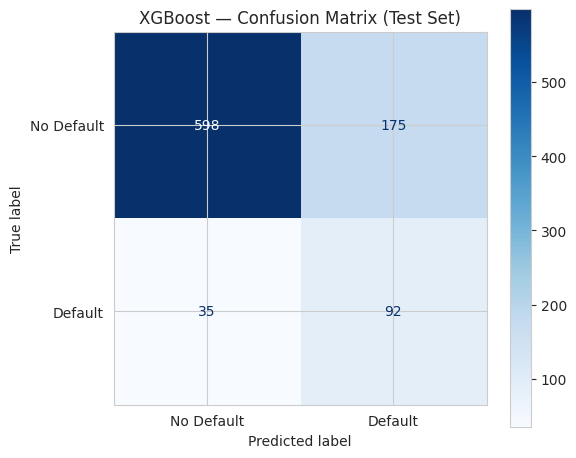

True Negatives:  598  (correctly approved)
False Positives: 175  (good businesses incorrectly flagged as risky)
False Negatives: 35  (defaulters incorrectly approved — direct loss risk)
True Positives:  92  (correctly flagged as risky)


In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb_test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('XGBoost — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}  (correctly approved)")
print(f"False Positives: {fp}  (good businesses incorrectly flagged as risky)")
print(f"False Negatives: {fn}  (defaulters incorrectly approved — direct loss risk)")
print(f"True Positives:  {tp}  (correctly flagged as risky)")

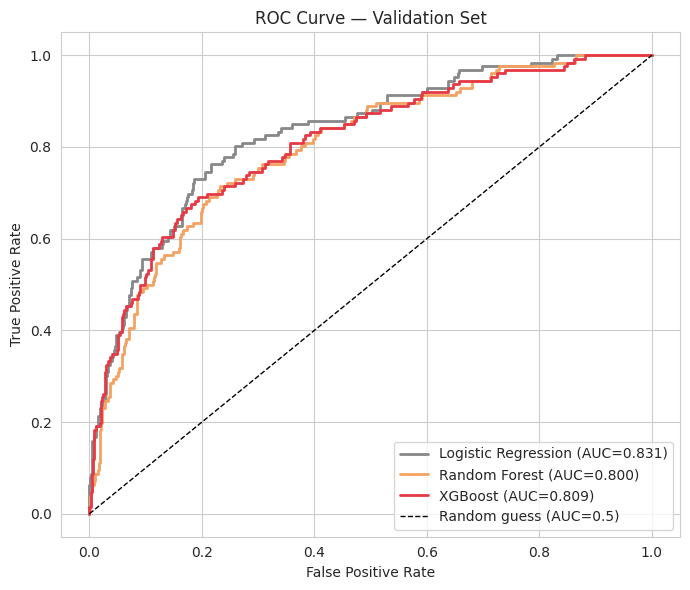

In [ ]:
# ROC Curve (All Three Models)
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
for name, proba, color in [
    ('Logistic Regression', lr_val_proba, '#888888'),
    ('Random Forest', rf_val_proba, '#F4A261'),
    ('XGBoost', xgb_val_proba, '#E63946'),
]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_score = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1, label='Random guess (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Validation Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

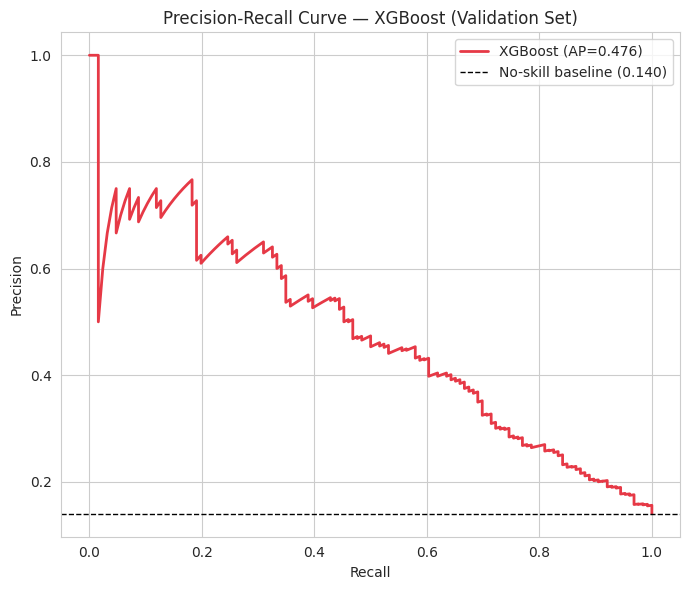

In [ ]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(7, 6))
precision_vals, recall_vals, _ = precision_recall_curve(y_val, xgb_val_proba)
ap_score = average_precision_score(y_val, xgb_val_proba)
ax.plot(recall_vals, precision_vals, color='#E63946', linewidth=2, label=f'XGBoost (AP={ap_score:.3f})')

baseline_rate = y_val.mean()
ax.axhline(baseline_rate, linestyle='--', color='black', linewidth=1,
           label=f'No-skill baseline ({baseline_rate:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — XGBoost (Validation Set)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-Validation Robustness Check
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    XGBClassifier(**random_search.best_params_, scale_pos_weight=scale_pos_weight,
                  eval_metric='auc', random_state=42, n_jobs=-1),
    X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='roc_auc'
)

print("5-fold CV ROC-AUC scores:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean():.4f}  |  Std Dev: {cv_scores.std():.4f}")

5-fold CV ROC-AUC scores: [0.7985 0.8136 0.8324 0.811  0.7999]
Mean: 0.8111  |  Std Dev: 0.0122


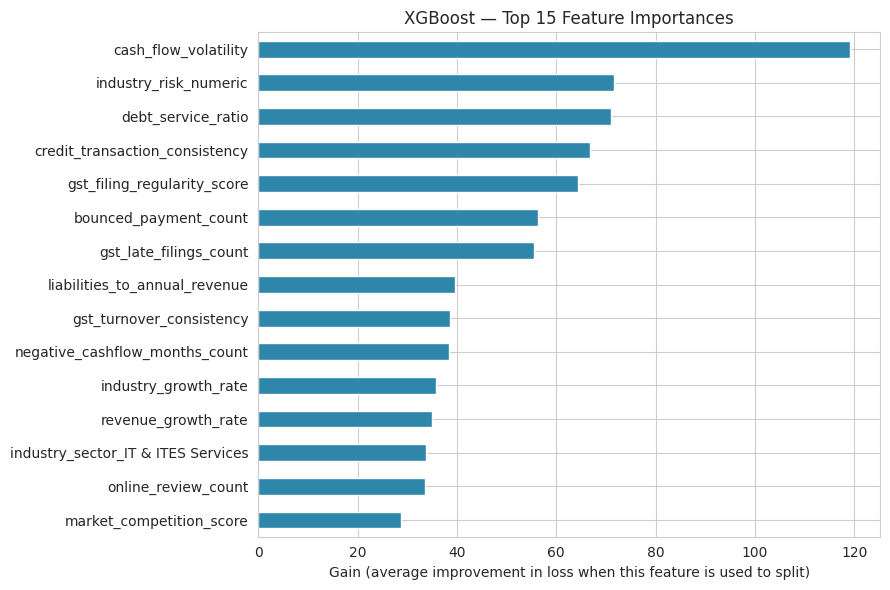

In [ ]:
# XGBoost Feature Importance (Preview Before SHAP)
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')
importance_series = pd.Series(importance_dict).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
importance_series.sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_xlabel('Gain (average improvement in loss when this feature is used to split)')
ax.set_title('XGBoost — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
# Derive the Credit Score Formula
import numpy as np

# Get the model's predicted probabilities on the TRAINING set only (never calibrate using test data)
train_proba_for_calibration = xgb_model.predict_proba(X_train)[:, 1]

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)  # avoid log(0) at the extremes
    return np.log(p / (1 - p))

# Anchor points: the "safest" 1% and "riskiest" 1% of applicants in our training data
P1 = np.percentile(train_proba_for_calibration, 1)
P99 = np.percentile(train_proba_for_calibration, 99)
L1, L99 = logit(P1), logit(P99)

SCORE_MAX, SCORE_MIN = 900, 300

# Linear mapping in log-odds space: L1 -> SCORE_MAX, L99 -> SCORE_MIN
SCORE_FACTOR = -(SCORE_MAX - SCORE_MIN) / (L99 - L1)
SCORE_OFFSET = SCORE_MAX - SCORE_FACTOR * L1

def probability_to_credit_score(probability):
    """
    Converts a model-predicted default probability into a project-specific
    300-900 credit score. This is NOT the CIBIL formula or any bank's
    proprietary methodology — it's a standard log-odds scaling technique,
    calibrated to THIS project's model and data.
    Lower default probability -> higher score. Monotonic by construction.
    """
    probability = np.asarray(probability, dtype=float)
    raw_score = SCORE_OFFSET + SCORE_FACTOR * logit(probability)
    return np.clip(raw_score, SCORE_MIN, SCORE_MAX)

print(f"Calibration anchors: P1={P1:.4f} (logit={L1:.3f}) -> score 900")
print(f"                      P99={P99:.4f} (logit={L99:.3f}) -> score 300")
print(f"SCORE_FACTOR={SCORE_FACTOR:.3f}, SCORE_OFFSET={SCORE_OFFSET:.3f}")

# Sanity check across a spread of probabilities
print("\nVerification table:")
print(f"{'probability':>12} {'score':>8}")
for p in [0.001, 0.05, 0.10, 0.14, 0.30, 0.50, 0.70, 0.90, 0.99]:
    print(f"{p:12.3f} {probability_to_credit_score(p):8.1f}")

Calibration anchors: P1=0.0465 (logit=-3.021) -> score 900
                      P99=0.8872 (logit=2.062) -> score 300
SCORE_FACTOR=-118.038, SCORE_OFFSET=543.447

Verification table:
 probability    score
       0.001    900.0
       0.050    891.0
       0.100    802.8
       0.140    757.7
       0.300    643.5
       0.500    543.4
       0.700    443.4
       0.900    300.0
       0.990    300.0


In [ ]:
# Apply the Score & Verify the Distribution
train_scores = probability_to_credit_score(train_proba_for_calibration)

print("Credit score distribution across the training set:")
for pct in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  p{pct}: {np.percentile(train_scores, pct):.1f}")
print(f"  min: {train_scores.min():.1f}  max: {train_scores.max():.1f}  mean: {train_scores.mean():.1f}")

Credit score distribution across the training set:
  p1: 300.0
  p5: 374.2
  p25: 523.1
  p50: 630.1
  p75: 732.6
  p95: 849.8
  p99: 900.0
  min: 300.0  max: 900.0  mean: 625.2


In [ ]:
# Define Risk Categories & Verify Against Actual Outcomes
def risk_category(score):
    """
    Project-specific risk bands. Thresholds are round-number choices dividing
    the 300-900 range into five roughly-even bands — not a copy of any
    external agency's published cutoffs.
    """
    if score >= 750:
        return 'Excellent'
    elif score >= 650:
        return 'Good'
    elif score >= 550:
        return 'Moderate'
    elif score >= 450:
        return 'High Risk'
    else:
        return 'Very High Risk'

train_categories = pd.Series([risk_category(s) for s in train_scores])
band_order = ['Excellent', 'Good', 'Moderate', 'High Risk', 'Very High Risk']

print(f"{'Category':16s} {'% of applicants':>16s} {'Observed default rate':>24s}")
for band in band_order:
    mask = (train_categories == band).values
    n = mask.sum()
    pct = n / len(mask) * 100
    observed_default_rate = y_train.values[mask].mean() * 100 if n > 0 else float('nan')
    print(f"{band:16s} {pct:15.1f}% {observed_default_rate:23.2f}%")

Category          % of applicants    Observed default rate
Excellent                   21.3%                    0.22%
Good                        23.7%                    1.61%
Moderate                    24.3%                    6.36%
High Risk                   18.4%                   22.09%
Very High Risk              12.2%                   65.69%


In [ ]:
# Define Loan Eligibility Rules (Business Logic Layer)
# Thresholds chosen with reference to the actual data distribution :
# each one measurably separates higher-default from lower-default applicants,
# and each is independently justifiable to a human reviewer without reference
# to the ML model at all.
MAX_DEBT_SERVICE_RATIO = 0.45      # >45% of revenue going to existing debt is a hard stop
MIN_BUSINESS_AGE_YEARS = 1.0       # at least one year of operating history
MIN_GST_FILING_REGULARITY = 0.4    # basic compliance floor
MIN_NET_MONTHLY_CASHFLOW = 0       # must not already be cash-flow negative before any new loan

def loan_eligibility_decision(credit_score_value, business_age_years, debt_service_ratio,
                               gst_filing_regularity_score, net_monthly_cashflow):
    """
    Combines the ML-derived credit score with independent, human-readable
    business rules. A high score does NOT guarantee eligibility if a hard
    rule fails — this is deliberate.
    """
    category = risk_category(credit_score_value)
    failed_rules = []

    if business_age_years < MIN_BUSINESS_AGE_YEARS:
        failed_rules.append(f"Business age ({business_age_years:.1f} yrs) is below the {MIN_BUSINESS_AGE_YEARS}-yr minimum")
    if debt_service_ratio > MAX_DEBT_SERVICE_RATIO:
        failed_rules.append(f"Debt-service ratio ({debt_service_ratio:.2f}) exceeds the {MAX_DEBT_SERVICE_RATIO} maximum")
    if gst_filing_regularity_score < MIN_GST_FILING_REGULARITY:
        failed_rules.append(f"GST filing regularity ({gst_filing_regularity_score:.2f}) is below the {MIN_GST_FILING_REGULARITY} minimum")
    if net_monthly_cashflow < MIN_NET_MONTHLY_CASHFLOW:
        failed_rules.append(f"Net monthly cash flow (INR {net_monthly_cashflow:,.0f}) is negative")

    if failed_rules:
        eligibility_status = "Not Eligible (Business Rule Failure)"
    elif category == 'Excellent':
        eligibility_status = "Eligible - Preferred Terms"
    elif category == 'Good':
        eligibility_status = "Eligible - Standard Terms"
    elif category == 'Moderate':
        eligibility_status = "Eligible - Enhanced Due Diligence"
    elif category == 'High Risk':
        eligibility_status = "Not Eligible - Refer for Manual Review"
    else:
        eligibility_status = "Not Eligible"

    return {
        'risk_category': category,
        'eligibility_status': eligibility_status,
        'failed_rules': failed_rules
    }

# Quick test: a good score that should STILL fail on a hard rule
test_result = loan_eligibility_decision(
    credit_score_value=720, business_age_years=0.5,   # too young despite good score
    debt_service_ratio=0.10, gst_filing_regularity_score=0.8, net_monthly_cashflow=200000
)
print("Test — good score, young business:")
print(" ", test_result)

Test — good score, young business:
  {'risk_category': 'Good', 'eligibility_status': 'Not Eligible (Business Rule Failure)', 'failed_rules': ['Business age (0.5 yrs) is below the 1.0-yr minimum']}


In [ ]:
# Test the Full Engine on Three Sample Applicants
def build_feature_vector(overrides):
    """Builds a full 46-column feature vector, defaulting everything to 0
    except the fields explicitly provided. Matches MODEL_FEATURE_COLUMNS order."""
    base = {col: 0 for col in MODEL_FEATURE_COLUMNS}
    base.update(overrides)
    return pd.DataFrame([base])[MODEL_FEATURE_COLUMNS]

strong_applicant = build_feature_vector({
    'business_age_years': 8, 'industry_risk_numeric': 0, 'industry_growth_rate': 10,
    'avg_monthly_revenue': 2000000, 'revenue_growth_rate': 12, 'profit_margin': 22,
    'cash_flow_volatility': 0.15, 'min_monthly_balance': 800000, 'existing_total_liabilities': 1000000,
    'existing_monthly_debt_obligation': 40000, 'debt_service_ratio': 0.02, 'working_capital_cycle_days': 30,
    'num_transactions_per_month': 120, 'credit_transaction_consistency': 0.9, 'cash_deposit_frequency': 8,
    'recurring_revenue_ratio': 0.8, 'gst_filing_regularity_score': 0.95, 'gst_turnover_consistency': 0.9,
    'has_website': 1, 'has_google_listing': 1, 'has_social_media': 1, 'online_review_count': 120,
    'online_review_rating': 4.5, 'local_unemployment_rate': 5.5, 'local_inflation_rate': 5.0,
    'local_demand_index': 80, 'market_competition_score': 70, 'regional_business_growth_rate': 8,
    'cash_buffer_months': 2.5, 'net_monthly_cashflow': 500000, 'free_cash_flow_ratio': 0.25,
    'liabilities_to_annual_revenue': 0.04, 'industry_sector_IT & ITES Services': 1, 'location_type_Urban': 1,
})

average_applicant = build_feature_vector({
    # every value here is the ACTUAL median of the training data for that column
    'business_age_years': 5.0, 'industry_risk_numeric': 1, 'industry_growth_rate': 7.0,
    'avg_monthly_revenue': 1000000, 'revenue_growth_rate': 7.0, 'profit_margin': 30,
    'cash_flow_volatility': 0.26, 'negative_cashflow_months_count': 3, 'min_monthly_balance': 650000,
    'existing_total_liabilities': 2500000, 'existing_monthly_debt_obligation': 80000, 'debt_service_ratio': 0.08,
    'working_capital_cycle_days': 45, 'num_transactions_per_month': 47, 'credit_transaction_consistency': 0.72,
    'cash_deposit_frequency': 4, 'recurring_revenue_ratio': 0.53, 'gst_filing_regularity_score': 0.77,
    'gst_late_filings_count': 1, 'gst_turnover_consistency': 0.73, 'has_website': 1, 'has_google_listing': 1,
    'online_review_count': 20, 'online_review_rating': 4.0, 'local_unemployment_rate': 7.2,
    'local_inflation_rate': 5.0, 'local_demand_index': 65, 'market_competition_score': 67,
    'regional_business_growth_rate': 6.3, 'cash_buffer_months': 1.5, 'net_monthly_cashflow': 187000,
    'free_cash_flow_ratio': 0.22, 'liabilities_to_annual_revenue': 0.23,
    'industry_sector_Trading & Retail': 1, 'location_type_Semi-Urban': 1,
})

risky_applicant = build_feature_vector({
    'business_age_years': 1.2, 'industry_risk_numeric': 2, 'industry_growth_rate': 4.5,
    'avg_monthly_revenue': 200000, 'revenue_growth_rate': -3, 'profit_margin': 5,
    'cash_flow_volatility': 0.75, 'negative_cashflow_months_count': 6, 'min_monthly_balance': 5000,
    'existing_total_liabilities': 500000, 'existing_monthly_debt_obligation': 45000, 'debt_service_ratio': 0.55,
    'working_capital_cycle_days': 90, 'num_transactions_per_month': 15, 'credit_transaction_consistency': 0.25,
    'bounced_payment_count': 5, 'recurring_revenue_ratio': 0.1, 'gst_filing_regularity_score': 0.35,
    'gst_late_filings_count': 7, 'gst_turnover_consistency': 0.3, 'online_review_count': 2,
    'online_review_rating': 2.5, 'local_unemployment_rate': 9.5, 'local_inflation_rate': 5.5,
    'local_demand_index': 40, 'market_competition_score': 30, 'regional_business_growth_rate': 3,
    'cash_buffer_months': 0.3, 'net_monthly_cashflow': -25000, 'free_cash_flow_ratio': -0.12,
    'liabilities_to_annual_revenue': 0.21, 'industry_sector_Agriculture & Allied': 1, 'location_type_Rural': 1,
})

print(f"{'Applicant':10s} {'Probability':>12s} {'Score':>7s} {'Category':>16s}  Eligibility")
print("-" * 90)
for name, vector in [('STRONG', strong_applicant), ('AVERAGE', average_applicant), ('RISKY', risky_applicant)]:
    prob = xgb_model.predict_proba(vector)[0, 1]
    score = float(probability_to_credit_score(prob))
    result = loan_eligibility_decision(
        score, vector['business_age_years'].iloc[0], vector['debt_service_ratio'].iloc[0],
        vector['gst_filing_regularity_score'].iloc[0], vector['net_monthly_cashflow'].iloc[0]
    )
    print(f"{name:10s} {prob:12.4f} {score:7.0f} {result['risk_category']:>16s}  {result['eligibility_status']}")
    if result['failed_rules']:
        for r in result['failed_rules']:
            print(f"             -> {r}")

Applicant   Probability   Score         Category  Eligibility
------------------------------------------------------------------------------------------
STRONG           0.0200     900        Excellent  Eligible - Preferred Terms
AVERAGE          0.1816     721             Good  Eligible - Standard Terms
RISKY            0.8681     321   Very High Risk  Not Eligible (Business Rule Failure)
             -> Debt-service ratio (0.55) exceeds the 0.45 maximum
             -> GST filing regularity (0.35) is below the 0.4 minimum
             -> Net monthly cash flow (INR -25,000) is negative


In [ ]:
# Save Scoring Configuration
import json

scoring_config = {
    'score_range': {'min': SCORE_MIN, 'max': SCORE_MAX},
    'score_formula': {
        'calibration_percentile_low': 1, 'calibration_percentile_high': 99,
        'P1': float(P1), 'P99': float(P99),
        'SCORE_FACTOR': float(SCORE_FACTOR), 'SCORE_OFFSET': float(SCORE_OFFSET),
    },
    'risk_bands': {
        'Excellent': [750, 900], 'Good': [650, 749], 'Moderate': [550, 649],
        'High Risk': [450, 549], 'Very High Risk': [300, 449],
    },
    'eligibility_rules': {
        'MAX_DEBT_SERVICE_RATIO': MAX_DEBT_SERVICE_RATIO,
        'MIN_BUSINESS_AGE_YEARS': MIN_BUSINESS_AGE_YEARS,
        'MIN_GST_FILING_REGULARITY': MIN_GST_FILING_REGULARITY,
        'MIN_NET_MONTHLY_CASHFLOW': MIN_NET_MONTHLY_CASHFLOW,
    }
}

with open('model/scoring_configuration.json', 'w') as f:
    json.dump(scoring_config, f, indent=2)

print("Saved model/scoring_configuration.json")
print(json.dumps(scoring_config, indent=2))

Saved model/scoring_configuration.json
{
  "score_range": {
    "min": 300,
    "max": 900
  },
  "score_formula": {
    "calibration_percentile_low": 1,
    "calibration_percentile_high": 99,
    "P1": 0.04650098830461502,
    "P99": 0.8871987462043762,
    "SCORE_FACTOR": -118.03805541992188,
    "SCORE_OFFSET": 543.4465942382812
  },
  "risk_bands": {
    "Excellent": [
      750,
      900
    ],
    "Good": [
      650,
      749
    ],
    "Moderate": [
      550,
      649
    ],
    "High Risk": [
      450,
      549
    ],
    "Very High Risk": [
      300,
      449
    ]
  },
  "eligibility_rules": {
    "MAX_DEBT_SERVICE_RATIO": 0.45,
    "MIN_BUSINESS_AGE_YEARS": 1.0,
    "MIN_GST_FILING_REGULARITY": 0.4,
    "MIN_NET_MONTHLY_CASHFLOW": 0
  }
}


In [ ]:
model_path = 'model/sme_credit_xgb.json'
xgb_model.save_model(model_path)

print("XGBoost model saved successfully to:", model_path)

XGBoost model saved successfully to: model/sme_credit_xgb.json


In [ ]:
from xgboost import XGBClassifier
import numpy as np

loaded_model = XGBClassifier()
loaded_model.load_model('model/sme_credit_xgb.json')

original_pred = xgb_model.predict_proba(X_test)[:, 1]
loaded_pred = loaded_model.predict_proba(X_test)[:, 1]

max_difference = np.max(np.abs(original_pred - loaded_pred))

print("Maximum prediction difference:", max_difference)

if max_difference < 1e-10:
    print("PASS: Model save/load verified successfully.")
else:
    print("WARNING: Difference detected.")

Maximum prediction difference: 0.0
PASS: Model save/load verified successfully.


In [ ]:
# Generate credit scores for the completely unseen test set

test_scores = probability_to_credit_score(xgb_test_proba)

test_categories = pd.Series(
    [risk_category(score) for score in test_scores],
    index=y_test.index
)

print("TEST SET — CREDIT SCORE DISTRIBUTION")
print("=" * 55)

for pct in [1, 5, 25, 50, 75, 95, 99]:
    print(f"p{pct:>2}: {np.percentile(test_scores, pct):.1f}")

print(f"\nMinimum score : {test_scores.min():.1f}")
print(f"Maximum score : {test_scores.max():.1f}")
print(f"Mean score    : {test_scores.mean():.1f}")
print(f"Median score  : {np.median(test_scores):.1f}")

TEST SET — CREDIT SCORE DISTRIBUTION
p 1: 300.0
p 5: 387.8
p25: 516.0
p50: 625.3
p75: 727.0
p95: 839.5
p99: 900.0

Minimum score : 300.0
Maximum score : 900.0
Mean score    : 621.0
Median score  : 625.3


In [ ]:
# Validate whether lower credit scores correspond to higher observed default rates

print("TEST SET — RISK BAND VALIDATION")
print("=" * 75)

for band in band_order:
    mask = test_categories == band
    count = mask.sum()

    if count > 0:
        default_rate = y_test.loc[mask].mean() * 100
        avg_score = test_scores[mask.values].mean()

        print(
            f"{band:16s} | "
            f"Applicants: {count:4d} | "
            f"Avg Score: {avg_score:7.1f} | "
            f"Observed Default Rate: {default_rate:6.2f}%"
        )
    else:
        print(f"{band:16s} | Applicants: 0")

TEST SET — RISK BAND VALIDATION
Excellent        | Applicants:  180 | Avg Score:   811.8 | Observed Default Rate:   1.11%
Good             | Applicants:  226 | Avg Score:   696.9 | Observed Default Rate:   4.42%
Moderate         | Applicants:  211 | Avg Score:   597.1 | Observed Default Rate:  10.43%
High Risk        | Applicants:  169 | Avg Score:   501.3 | Observed Default Rate:  24.26%
Very High Risk   | Applicants:  114 | Avg Score:   391.0 | Observed Default Rate:  45.61%


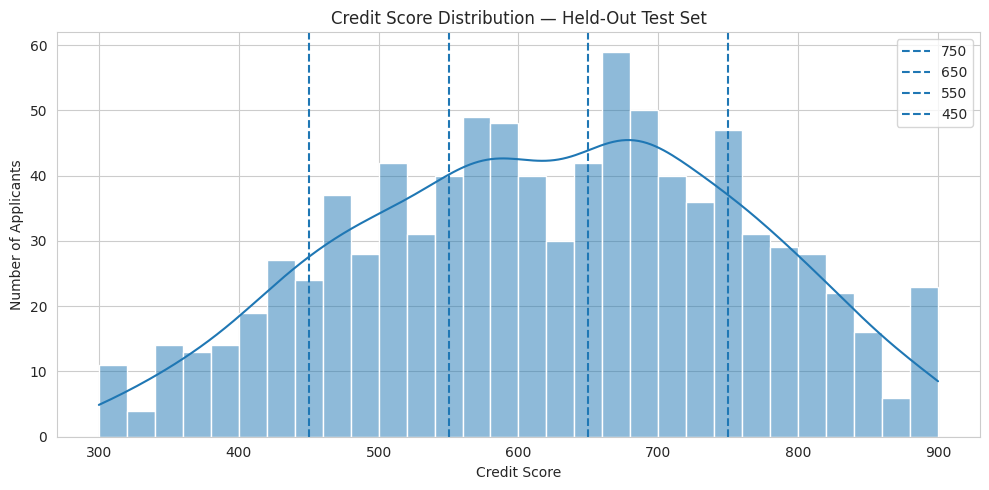

In [ ]:
# Visualize the Credit Score Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    test_scores,
    bins=30,
    kde=True
)

plt.axvline(750, linestyle='--', label='750')
plt.axvline(650, linestyle='--', label='650')
plt.axvline(550, linestyle='--', label='550')
plt.axvline(450, linestyle='--', label='450')

plt.xlabel('Credit Score')
plt.ylabel('Number of Applicants')
plt.title('Credit Score Distribution — Held-Out Test Set')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create a detailed test-set scoring table

test_results = df_encoded.loc[y_test.index, [
    'business_id',
    'default_label'
]].copy()

test_results['predicted_default_probability'] = xgb_test_proba
test_results['credit_score'] = test_scores
test_results['risk_category'] = test_categories.values

test_results = test_results.sort_values(
    'credit_score',
    ascending=False
)

display(test_results.head(10))

,business_id,default_label,predicted_default_probability,credit_score,risk_category
2156,SME_02156,0,0.029713,900.0,Excellent
692,SME_00692,0,0.038853,900.0,Excellent
798,SME_00798,0,0.043697,900.0,Excellent
5637,SME_05637,0,0.042861,900.0,Excellent
715,SME_00715,0,0.042954,900.0,Excellent
1393,SME_01393,0,0.044605,900.0,Excellent
143,SME_00143,0,0.042678,900.0,Excellent
3574,SME_03574,0,0.036478,900.0,Excellent
1338,SME_01338,0,0.036605,900.0,Excellent
5283,SME_05283,0,0.043626,900.0,Excellent


In [ ]:
display(test_results.tail(10))

,business_id,default_label,predicted_default_probability,credit_score,risk_category
2818,SME_02818,1,0.898557,300.0,Very High Risk
5956,SME_05956,1,0.908441,300.0,Very High Risk
4492,SME_04492,1,0.944701,300.0,Very High Risk
4167,SME_04167,1,0.901201,300.0,Very High Risk
34,SME_00034,1,0.909934,300.0,Very High Risk
5519,SME_05519,1,0.913443,300.0,Very High Risk
2410,SME_02410,1,0.925049,300.0,Very High Risk
2592,SME_02592,1,0.937595,300.0,Very High Risk
3044,SME_03044,1,0.902098,300.0,Very High Risk
2109,SME_02109,1,0.931508,300.0,Very High Risk


In [ ]:
import json
from datetime import datetime

model_metadata = {
    "model_type": "XGBoost Classifier",
    "model_purpose": "SME credit risk prediction",
    "dataset_type": "Synthetic",
    "random_state": 42,
    "n_samples": int(len(df_encoded)),
    "n_features": int(len(MODEL_FEATURE_COLUMNS)),
    "train_samples": int(len(X_train)),
    "validation_samples": int(len(X_val)),
    "test_samples": int(len(X_test)),
    "test_roc_auc": float(roc_auc_score(y_test, xgb_test_proba)),
    "test_pr_auc": float(average_precision_score(y_test, xgb_test_proba)),
    "test_accuracy": float(accuracy_score(y_test, xgb_test_pred)),
    "test_precision": float(precision_score(y_test, xgb_test_pred)),
    "test_recall": float(recall_score(y_test, xgb_test_pred)),
    "test_f1": float(f1_score(y_test, xgb_test_pred)),
    "credit_score_range": [300, 900],
    "created_at": datetime.now().isoformat()
}

with open('model/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("Model metadata saved successfully.")
print(json.dumps(model_metadata, indent=2))

Model metadata saved successfully.
{
  "model_type": "XGBoost Classifier",
  "model_purpose": "SME credit risk prediction",
  "dataset_type": "Synthetic",
  "random_state": 42,
  "n_samples": 6000,
  "n_features": 46,
  "train_samples": 4200,
  "validation_samples": 900,
  "test_samples": 900,
  "test_roc_auc": 0.8161371484450601,
  "test_pr_auc": 0.44800910697407187,
  "test_accuracy": 0.7666666666666667,
  "test_precision": 0.3445692883895131,
  "test_recall": 0.7244094488188977,
  "test_f1": 0.467005076142132,
  "credit_score_range": [
    300,
    900
  ],
  "created_at": "2026-09-13T09:29:12.557862"
}


In [ ]:
# ============================================================
# RAW APPLICANT → MODEL FEATURE ENGINEERING
# ============================================================

def prepare_applicant_features(applicant):
    """
    Converts raw SME applicant information into the exact
    46-feature vector required by the trained XGBoost model.

    The function reproduces the feature engineering decisions
    used during model development.
    """

    applicant = applicant.copy()

    # --------------------------------------------------------
    # Basic validation
    # --------------------------------------------------------

    required_fields = [
        'industry_sector',
        'location_type',
        'business_age_years',
        'avg_monthly_revenue',
        'revenue_growth_rate',
        'avg_monthly_expenses',
        'cash_flow_volatility',
        'negative_cashflow_months_count',
        'avg_monthly_cash_balance',
        'min_monthly_balance',
        'existing_total_liabilities',
        'existing_monthly_debt_obligation',
        'working_capital_cycle_days',
        'num_transactions_per_month',
        'credit_transaction_consistency',
        'cash_deposit_frequency',
        'bounced_payment_count',
        'recurring_revenue_ratio',
        'gst_filing_regularity_score',
        'gst_late_filings_count',
        'gst_turnover_consistency',
        'has_website',
        'has_google_listing',
        'has_social_media',
        'online_review_count',
        'online_review_rating'
    ]

    missing_fields = [
        field for field in required_fields
        if field not in applicant
    ]

    if missing_fields:
        raise ValueError(
            f"Missing required applicant fields: {missing_fields}"
        )

    # --------------------------------------------------------
    # Basic sanity checks
    # --------------------------------------------------------

    if applicant['avg_monthly_revenue'] <= 0:
        raise ValueError("Average monthly revenue must be greater than 0.")

    if applicant['avg_monthly_expenses'] < 0:
        raise ValueError("Average monthly expenses cannot be negative.")

    if applicant['business_age_years'] < 0:
        raise ValueError("Business age cannot be negative.")

    # --------------------------------------------------------
    # Industry reference information
    # --------------------------------------------------------

    industry = applicant['industry_sector']

    if industry not in INDUSTRY_TABLE:
        raise ValueError(f"Unknown industry sector: {industry}")

    industry_info = INDUSTRY_TABLE[industry]

    industry_growth_rate = industry_info['growth']
    industry_risk_level = industry_info['risk']

    industry_risk_numeric = RISK_NUM[industry_risk_level]

    # --------------------------------------------------------
    # Location reference information
    # --------------------------------------------------------

    location = applicant['location_type']

    if location not in LOCATION_TABLE:
        raise ValueError(f"Unknown location type: {location}")

    location_info = LOCATION_TABLE[location]

    # Use the project's location reference assumptions
    local_unemployment_rate = location_info['unemployment']
    local_inflation_rate = location_info['inflation']
    local_demand_index = location_info['demand']
    market_competition_score = location_info['competition']
    regional_business_growth_rate = location_info['growth']

    # --------------------------------------------------------
    # Financial feature engineering
    # --------------------------------------------------------

    revenue = applicant['avg_monthly_revenue']
    expenses = applicant['avg_monthly_expenses']
    debt_payment = applicant['existing_monthly_debt_obligation']

    profit_margin = (
        (revenue - expenses) / revenue
    ) * 100

    net_monthly_cashflow = (
        revenue
        - expenses
        - debt_payment
    )

    free_cash_flow_ratio = (
        net_monthly_cashflow / revenue
    )

    debt_service_ratio = (
        debt_payment / revenue
    )

    cash_buffer_months = (
        applicant['avg_monthly_cash_balance'] / expenses
        if expenses > 0 else 0
    )

    liabilities_to_annual_revenue = (
        applicant['existing_total_liabilities']
        / (revenue * 12)
    )

    # --------------------------------------------------------
    # Build raw feature dictionary
    # --------------------------------------------------------

    data = {

        # Business
        'business_age_years': applicant['business_age_years'],
        'industry_risk_numeric': industry_risk_numeric,
        'industry_growth_rate': industry_growth_rate,

        # Financial
        'avg_monthly_revenue': revenue,
        'revenue_growth_rate': applicant['revenue_growth_rate'],
        'profit_margin': profit_margin,
        'cash_flow_volatility': applicant['cash_flow_volatility'],
        'negative_cashflow_months_count': applicant['negative_cashflow_months_count'],
        'min_monthly_balance': applicant['min_monthly_balance'],
        'existing_total_liabilities': applicant['existing_total_liabilities'],
        'existing_monthly_debt_obligation': debt_payment,
        'debt_service_ratio': debt_service_ratio,
        'working_capital_cycle_days': applicant['working_capital_cycle_days'],

        # Bank behaviour
        'num_transactions_per_month': applicant['num_transactions_per_month'],
        'credit_transaction_consistency': applicant['credit_transaction_consistency'],
        'cash_deposit_frequency': applicant['cash_deposit_frequency'],
        'bounced_payment_count': applicant['bounced_payment_count'],
        'recurring_revenue_ratio': applicant['recurring_revenue_ratio'],

        # GST
        'gst_filing_regularity_score': applicant['gst_filing_regularity_score'],
        'gst_late_filings_count': applicant['gst_late_filings_count'],
        'gst_turnover_consistency': applicant['gst_turnover_consistency'],

        # Digital
        'has_website': applicant['has_website'],
        'has_google_listing': applicant['has_google_listing'],
        'has_social_media': applicant['has_social_media'],
        'online_review_count': applicant['online_review_count'],
        'online_review_rating': applicant['online_review_rating'],

        # Local market
        'local_unemployment_rate': local_unemployment_rate,
        'local_inflation_rate': local_inflation_rate,
        'local_demand_index': local_demand_index,
        'market_competition_score': market_competition_score,
        'regional_business_growth_rate': regional_business_growth_rate,

        # Engineered features
        'cash_buffer_months': cash_buffer_months,
        'net_monthly_cashflow': net_monthly_cashflow,
        'free_cash_flow_ratio': free_cash_flow_ratio,
        'liabilities_to_annual_revenue': liabilities_to_annual_revenue
    }

    # --------------------------------------------------------
    # Convert to DataFrame
    # --------------------------------------------------------

    row = pd.DataFrame([data])

    # --------------------------------------------------------
    # One-hot encode industry and location
    # --------------------------------------------------------

    row['industry_sector'] = industry
    row['location_type'] = location

    row = pd.get_dummies(
        row,
        columns=['industry_sector', 'location_type'],
        drop_first=True
    )

    # --------------------------------------------------------
    # Add any missing model columns
    # --------------------------------------------------------

    for column in MODEL_FEATURE_COLUMNS:

        if column not in row.columns:
            row[column] = 0

    # --------------------------------------------------------
    # Keep ONLY the exact model features in exact order
    # --------------------------------------------------------

    row = row[MODEL_FEATURE_COLUMNS]

    return row

In [ ]:
# ============================================================
# TEST APPLICANT FEATURE ENGINEERING
# ============================================================

test_applicant = {
    'industry_sector': 'IT & ITES Services',
    'location_type': 'Urban',

    'business_age_years': 8,
    'avg_monthly_revenue': 2_000_000,
    'revenue_growth_rate': 12,
    'avg_monthly_expenses': 1_500_000,

    'cash_flow_volatility': 0.15,
    'negative_cashflow_months_count': 1,
    'avg_monthly_cash_balance': 1_000_000,
    'min_monthly_balance': 800_000,

    'existing_total_liabilities': 1_000_000,
    'existing_monthly_debt_obligation': 40_000,
    'working_capital_cycle_days': 30,

    'num_transactions_per_month': 120,
    'credit_transaction_consistency': 0.90,
    'cash_deposit_frequency': 8,
    'bounced_payment_count': 0,
    'recurring_revenue_ratio': 0.80,

    'gst_filing_regularity_score': 0.95,
    'gst_late_filings_count': 0,
    'gst_turnover_consistency': 0.90,

    'has_website': 1,
    'has_google_listing': 1,
    'has_social_media': 1,
    'online_review_count': 120,
    'online_review_rating': 4.5
}

test_vector = prepare_applicant_features(test_applicant)

print("Feature vector shape:", test_vector.shape)
print("Expected shape:      ", (1, len(MODEL_FEATURE_COLUMNS)))

print("\nMissing values:")
print(test_vector.isna().sum().sum())

print("\nFeature order correct:")
print(list(test_vector.columns) == MODEL_FEATURE_COLUMNS)

print("\nGenerated features:")
display(test_vector.T)

Feature vector shape: (1, 46)
Expected shape:       (1, 46)

Missing values:
0

Feature order correct:
True

Generated features:


,0
business_age_years,8.000000e+00
industry_risk_numeric,0.000000e+00
industry_growth_rate,1.200000e+01
avg_monthly_revenue,2.000000e+06
revenue_growth_rate,1.200000e+01
profit_margin,2.500000e+01
cash_flow_volatility,1.500000e-01
negative_cashflow_months_count,1.000000e+00
min_monthly_balance,8.000000e+05
existing_total_liabilities,1.000000e+06


In [ ]:
# ============================================================
# COMPLETE SME CREDIT ASSESSMENT ENGINE
# ============================================================

def assess_sme(applicant):
    """
    Complete SME credit assessment pipeline.

    Returns:
        - default probability
        - credit score
        - risk category
        - eligibility status
        - failed eligibility rules
    """

    # --------------------------------------------------------
    # 1. Prepare model features
    # --------------------------------------------------------

    feature_vector = prepare_applicant_features(applicant)

    # --------------------------------------------------------
    # 2. Predict default probability
    # --------------------------------------------------------

    probability = float(
        loaded_model.predict_proba(feature_vector)[0, 1]
    )

    # --------------------------------------------------------
    # 3. Convert probability → credit score
    # --------------------------------------------------------

    credit_score = float(
        probability_to_credit_score(probability)
    )

    # --------------------------------------------------------
    # 4. Risk category
    # --------------------------------------------------------

    category = risk_category(credit_score)

    # --------------------------------------------------------
    # 5. Eligibility decision
    # --------------------------------------------------------

    eligibility = loan_eligibility_decision(
        credit_score_value=credit_score,
        business_age_years=applicant['business_age_years'],
        debt_service_ratio=feature_vector['debt_service_ratio'].iloc[0],
        gst_filing_regularity_score=applicant['gst_filing_regularity_score'],
        net_monthly_cashflow=feature_vector['net_monthly_cashflow'].iloc[0]
    )

    # --------------------------------------------------------
    # 6. Return complete result
    # --------------------------------------------------------

    return {
        'default_probability': probability,
        'credit_score': round(credit_score, 2),
        'risk_category': category,
        'eligibility_status': eligibility['eligibility_status'],
        'failed_rules': eligibility['failed_rules'],
        'feature_vector': feature_vector
    }

In [ ]:
# ============================================================
# TEST COMPLETE ASSESSMENT ENGINE
# ============================================================

result = assess_sme(test_applicant)

print("=" * 60)
print("             SME CREDIT ASSESSMENT")
print("=" * 60)

print(f"Default Probability : {result['default_probability']:.2%}")
print(f"Credit Score        : {result['credit_score']:.0f}")
print(f"Risk Category       : {result['risk_category']}")
print(f"Eligibility         : {result['eligibility_status']}")

print("\nEligibility Rule Checks:")
if result['failed_rules']:
    for rule in result['failed_rules']:
        print("  ✗", rule)
else:
    print("  ✓ All eligibility rules passed")

print("=" * 60)

             SME CREDIT ASSESSMENT
Default Probability : 2.59%
Credit Score        : 900
Risk Category       : Excellent
Eligibility         : Eligible - Preferred Terms

Eligibility Rule Checks:
  ✓ All eligibility rules passed


In [ ]:
# ============================================================
# THREE REALISTIC SME APPLICANT PROFILES
# ============================================================

strong_raw = {
    'industry_sector': 'IT & ITES Services',
    'location_type': 'Urban',
    'business_age_years': 8,
    'avg_monthly_revenue': 2_000_000,
    'revenue_growth_rate': 12,
    'avg_monthly_expenses': 1_500_000,
    'cash_flow_volatility': 0.15,
    'negative_cashflow_months_count': 1,
    'avg_monthly_cash_balance': 1_000_000,
    'min_monthly_balance': 800_000,
    'existing_total_liabilities': 1_000_000,
    'existing_monthly_debt_obligation': 40_000,
    'working_capital_cycle_days': 30,
    'num_transactions_per_month': 120,
    'credit_transaction_consistency': 0.90,
    'cash_deposit_frequency': 8,
    'bounced_payment_count': 0,
    'recurring_revenue_ratio': 0.80,
    'gst_filing_regularity_score': 0.95,
    'gst_late_filings_count': 0,
    'gst_turnover_consistency': 0.90,
    'has_website': 1,
    'has_google_listing': 1,
    'has_social_media': 1,
    'online_review_count': 120,
    'online_review_rating': 4.5
}


average_raw = {
    'industry_sector': 'Trading & Retail',
    'location_type': 'Semi-Urban',
    'business_age_years': 5,
    'avg_monthly_revenue': 1_000_000,
    'revenue_growth_rate': 7,
    'avg_monthly_expenses': 700_000,
    'cash_flow_volatility': 0.30,
    'negative_cashflow_months_count': 3,
    'avg_monthly_cash_balance': 500_000,
    'min_monthly_balance': 300_000,
    'existing_total_liabilities': 2_500_000,
    'existing_monthly_debt_obligation': 80_000,
    'working_capital_cycle_days': 45,
    'num_transactions_per_month': 50,
    'credit_transaction_consistency': 0.70,
    'cash_deposit_frequency': 4,
    'bounced_payment_count': 1,
    'recurring_revenue_ratio': 0.50,
    'gst_filing_regularity_score': 0.75,
    'gst_late_filings_count': 1,
    'gst_turnover_consistency': 0.72,
    'has_website': 1,
    'has_google_listing': 1,
    'has_social_media': 0,
    'online_review_count': 25,
    'online_review_rating': 4.0
}


risky_raw = {
    'industry_sector': 'Agriculture & Allied',
    'location_type': 'Rural',
    'business_age_years': 1.2,
    'avg_monthly_revenue': 200_000,
    'revenue_growth_rate': -3,
    'avg_monthly_expenses': 180_000,
    'cash_flow_volatility': 0.75,
    'negative_cashflow_months_count': 6,
    'avg_monthly_cash_balance': 30_000,
    'min_monthly_balance': 5_000,
    'existing_total_liabilities': 500_000,
    'existing_monthly_debt_obligation': 45_000,
    'working_capital_cycle_days': 90,
    'num_transactions_per_month': 15,
    'credit_transaction_consistency': 0.25,
    'cash_deposit_frequency': 2,
    'bounced_payment_count': 5,
    'recurring_revenue_ratio': 0.10,
    'gst_filing_regularity_score': 0.35,
    'gst_late_filings_count': 7,
    'gst_turnover_consistency': 0.30,
    'has_website': 0,
    'has_google_listing': 0,
    'has_social_media': 0,
    'online_review_count': 2,
    'online_review_rating': 2.5
}


profiles = {
    'STRONG': strong_raw,
    'AVERAGE': average_raw,
    'RISKY': risky_raw
}

print(
    f"{'Applicant':10s} "
    f"{'Probability':>12s} "
    f"{'Score':>8s} "
    f"{'Risk':>16s} "
    f"Eligibility"
)

print("-" * 100)

for name, applicant in profiles.items():

    result = assess_sme(applicant)

    print(
        f"{name:10s} "
        f"{result['default_probability']:12.2%} "
        f"{result['credit_score']:8.0f} "
        f"{result['risk_category']:>16s} "
        f"{result['eligibility_status']}"
    )

    if result['failed_rules']:
        for rule in result['failed_rules']:
            print(f"             → {rule}")

Applicant   Probability    Score             Risk Eligibility
----------------------------------------------------------------------------------------------------
STRONG            2.59%      900        Excellent Eligible - Preferred Terms
AVERAGE          32.14%      632         Moderate Eligible - Enhanced Due Diligence
RISKY            92.93%      300   Very High Risk Not Eligible (Business Rule Failure)
             → GST filing regularity (0.35) is below the 0.4 minimum
             → Net monthly cash flow (INR -25,000) is negative


In [ ]:
# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the verified loaded model
explainer = shap.TreeExplainer(loaded_model)

# Generate SHAP values for the held-out test set
shap_values = explainer.shap_values(X_test)

print("SHAP explainer created successfully.")
print("Test feature matrix shape:", X_test.shape)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP explainer created successfully.
Test feature matrix shape: (900, 46)
SHAP values shape: (900, 46)


In [ ]:
# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    'mean_abs_shap',
    ascending=False
)

print("TOP 20 FEATURES BY SHAP IMPORTANCE")
print("=" * 60)

display(shap_importance.head(20))

TOP 20 FEATURES BY SHAP IMPORTANCE


,feature,mean_abs_shap
6,cash_flow_volatility,0.447850
18,gst_filing_regularity_score,0.350604
11,debt_service_ratio,0.278333
19,gst_late_filings_count,0.214423
16,bounced_payment_count,0.194979
4,revenue_growth_rate,0.182163
14,credit_transaction_consistency,0.151996
1,industry_risk_numeric,0.129871
24,online_review_count,0.104257
7,negative_cashflow_months_count,0.088430


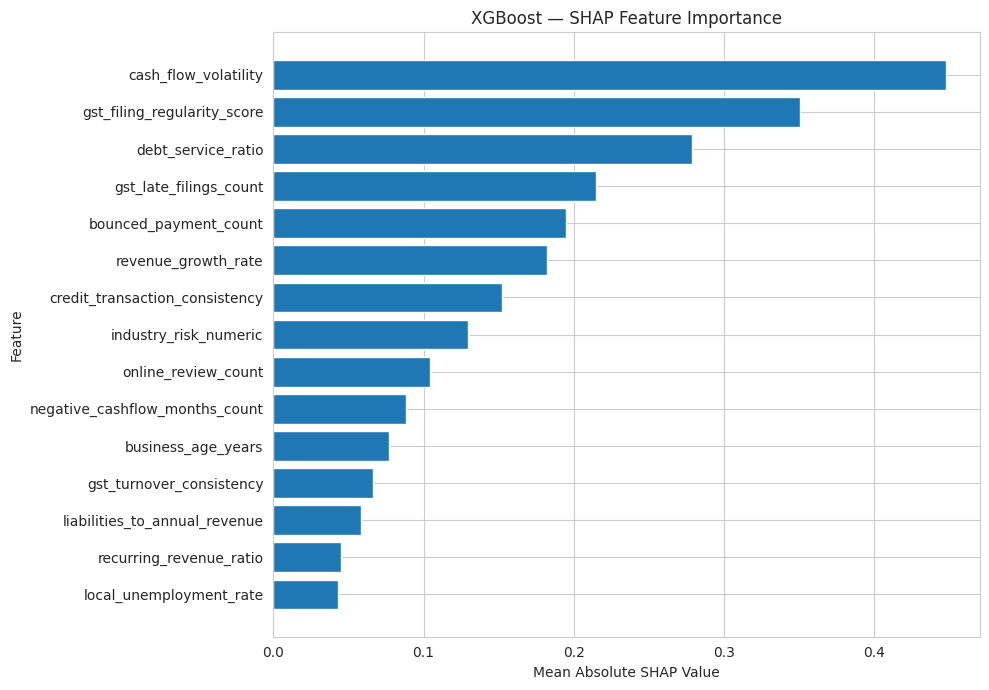

In [ ]:
plt.figure(figsize=(10, 7))

top_shap = shap_importance.head(15).sort_values(
    'mean_abs_shap'
)

plt.barh(
    top_shap['feature'],
    top_shap['mean_abs_shap']
)

plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.title('XGBoost — SHAP Feature Importance')

plt.tight_layout()
plt.show()

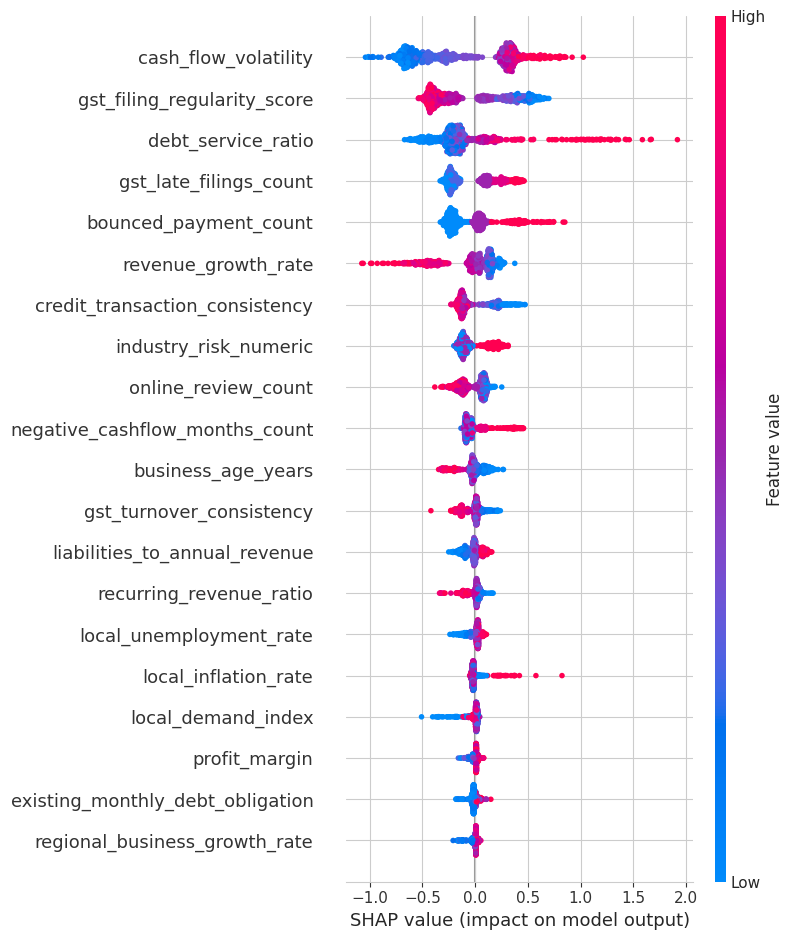

In [ ]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

In [ ]:
# ============================================================
# INDIVIDUAL APPLICANT SHAP EXPLANATION
# ============================================================

def explain_applicant(applicant, top_n=8):

    feature_vector = prepare_applicant_features(applicant)

    values = explainer.shap_values(feature_vector)

    values = np.asarray(values)

    if values.ndim == 2:
        values = values[0]

    explanation = pd.DataFrame({
        'feature': feature_vector.columns,
        'feature_value': feature_vector.iloc[0].values,
        'shap_value': values
    })

    explanation['direction'] = np.where(
        explanation['shap_value'] > 0,
        'Increases default risk',
        'Reduces default risk'
    )

    explanation['impact'] = np.abs(
        explanation['shap_value']
    )

    explanation = explanation.sort_values(
        'impact',
        ascending=False
    )

    return explanation.head(top_n)

In [ ]:
risky_explanation = explain_applicant(
    risky_raw,
    top_n=10
)

display(risky_explanation)

,feature,feature_value,shap_value,direction,impact
6,cash_flow_volatility,0.75,0.514107,Increases default risk,0.514107
16,bounced_payment_count,5.00,0.424204,Increases default risk,0.424204
18,gst_filing_regularity_score,0.35,0.391245,Increases default risk,0.391245
14,credit_transaction_consistency,0.25,0.289757,Increases default risk,0.289757
19,gst_late_filings_count,7.00,0.271774,Increases default risk,0.271774
7,negative_cashflow_months_count,6.00,0.244434,Increases default risk,0.244434
1,industry_risk_numeric,2.00,0.166875,Increases default risk,0.166875
24,online_review_count,2.00,0.164103,Increases default risk,0.164103
12,working_capital_cycle_days,90.00,-0.132522,Reduces default risk,0.132522
0,business_age_years,1.20,0.093418,Increases default risk,0.093418


In [ ]:
strong_explanation = explain_applicant(
    strong_raw,
    top_n=10
)

display(strong_explanation)

,feature,feature_value,shap_value,direction,impact
6,cash_flow_volatility,0.150000,-0.632497,Reduces default risk,0.632497
11,debt_service_ratio,0.020000,-0.417376,Reduces default risk,0.417376
18,gst_filing_regularity_score,0.950000,-0.416292,Reduces default risk,0.416292
4,revenue_growth_rate,12.000000,-0.362386,Reduces default risk,0.362386
19,gst_late_filings_count,0.000000,-0.330642,Reduces default risk,0.330642
24,online_review_count,120.000000,-0.232879,Reduces default risk,0.232879
16,bounced_payment_count,0.000000,-0.186006,Reduces default risk,0.186006
34,liabilities_to_annual_revenue,0.041667,-0.157681,Reduces default risk,0.157681
14,credit_transaction_consistency,0.900000,-0.147337,Reduces default risk,0.147337
20,gst_turnover_consistency,0.900000,-0.136159,Reduces default risk,0.136159


In [ ]:
# ============================================================
# HUMAN-READABLE FEATURE NAMES
# ============================================================

FEATURE_DISPLAY_NAMES = {
    'business_age_years': 'Business Age',
    'industry_risk_numeric': 'Industry Risk',
    'industry_growth_rate': 'Industry Growth',
    'avg_monthly_revenue': 'Monthly Revenue',
    'revenue_growth_rate': 'Revenue Growth',
    'profit_margin': 'Profit Margin',
    'cash_flow_volatility': 'Cash Flow Volatility',
    'negative_cashflow_months_count': 'Negative Cash-Flow Months',
    'min_monthly_balance': 'Minimum Bank Balance',
    'existing_total_liabilities': 'Existing Liabilities',
    'existing_monthly_debt_obligation': 'Existing Monthly Debt',
    'debt_service_ratio': 'Debt-Service Ratio',
    'working_capital_cycle_days': 'Working Capital Cycle',
    'num_transactions_per_month': 'Monthly Transactions',
    'credit_transaction_consistency': 'Transaction Consistency',
    'cash_deposit_frequency': 'Cash Deposit Frequency',
    'bounced_payment_count': 'Bounced Payments',
    'recurring_revenue_ratio': 'Recurring Revenue',
    'gst_filing_regularity_score': 'GST Filing Regularity',
    'gst_late_filings_count': 'GST Late Filings',
    'gst_turnover_consistency': 'GST Turnover Consistency',
    'has_website': 'Website Presence',
    'has_google_listing': 'Google Listing',
    'has_social_media': 'Social Media Presence',
    'online_review_count': 'Online Reviews',
    'online_review_rating': 'Online Review Rating',
    'local_unemployment_rate': 'Local Unemployment',
    'local_inflation_rate': 'Local Inflation',
    'local_demand_index': 'Local Demand',
    'market_competition_score': 'Market Competition',
    'regional_business_growth_rate': 'Regional Business Growth',
    'cash_buffer_months': 'Cash Buffer',
    'net_monthly_cashflow': 'Net Monthly Cash Flow',
    'free_cash_flow_ratio': 'Free Cash Flow Ratio',
    'liabilities_to_annual_revenue': 'Liabilities / Annual Revenue'
}


def humanize_feature_name(feature):

    if feature in FEATURE_DISPLAY_NAMES:
        return FEATURE_DISPLAY_NAMES[feature]

    if feature.startswith('industry_sector_'):
        return "Industry: " + feature.replace(
            'industry_sector_', ''
        )

    if feature.startswith('location_type_'):
        return "Location: " + feature.replace(
            'location_type_', ''
        )

    return feature.replace('_', ' ').title()

In [ ]:
# ============================================================
# LOAN OPTIMIZER
# ============================================================

LOAN_ANNUAL_INTEREST_RATE = 0.12
LOAN_TENURE_MONTHS = 36
MAX_TOTAL_DEBT_SERVICE_RATIO = 0.45


def calculate_emi(
    principal,
    annual_rate,
    months
):

    monthly_rate = annual_rate / 12

    if monthly_rate == 0:
        return principal / months

    emi = (
        principal
        * monthly_rate
        * (1 + monthly_rate) ** months
        / ((1 + monthly_rate) ** months - 1)
    )

    return emi


def calculate_max_loan_from_emi(
    available_monthly_payment,
    annual_rate=LOAN_ANNUAL_INTEREST_RATE,
    months=LOAN_TENURE_MONTHS
):

    if available_monthly_payment <= 0:
        return 0

    monthly_rate = annual_rate / 12

    if monthly_rate == 0:
        return available_monthly_payment * months

    loan_amount = (
        available_monthly_payment
        * ((1 + monthly_rate) ** months - 1)
        / (
            monthly_rate
            * (1 + monthly_rate) ** months
        )
    )

    return loan_amount

In [ ]:
# ============================================================
# RISK-ADJUSTED LOAN RECOMMENDATION
# ============================================================

def recommend_loan_amount(
    applicant,
    credit_score,
    eligibility_status
):

    revenue = applicant['avg_monthly_revenue']

    existing_debt_payment = (
        applicant['existing_monthly_debt_obligation']
    )

    # Maximum total debt payment allowed
    max_total_debt_service = (
        revenue * MAX_TOTAL_DEBT_SERVICE_RATIO
    )

    # Amount available for NEW loan EMI
    available_new_payment = (
        max_total_debt_service
        - existing_debt_payment
    )

    available_new_payment = max(
        available_new_payment,
        0
    )

    serviceability_amount = (
        calculate_max_loan_from_emi(
            available_new_payment
        )
    )

    risk_adjustments = {
        'Excellent': 1.00,
        'Good': 0.85,
        'Moderate': 0.65,
        'High Risk': 0.40,
        'Very High Risk': 0.00
    }

    adjustment = risk_adjustments[
        risk_category(credit_score)
    ]

    recommended_amount = (
        serviceability_amount * adjustment
    )

    # Hard eligibility failure overrides recommendation
    if eligibility_status.startswith("Not Eligible"):
        recommended_amount = 0

    return {
        'maximum_monthly_debt_service':
            round(max_total_debt_service, 2),

        'available_new_debt_service':
            round(available_new_payment, 2),

        'serviceability_loan_amount':
            round(serviceability_amount, 2),

        'risk_adjustment':
            adjustment,

        'recommended_loan_amount':
            round(recommended_amount, 2),

        'assumed_interest_rate':
            LOAN_ANNUAL_INTEREST_RATE,

        'assumed_tenure_months':
            LOAN_TENURE_MONTHS
    }

In [ ]:
# Test the Loan Optimizer
strong_result = assess_sme(strong_raw)

loan_result = recommend_loan_amount(
    strong_raw,
    strong_result['credit_score'],
    strong_result['eligibility_status']
)

print("LOAN RECOMMENDATION")
print("=" * 50)

for key, value in loan_result.items():
    print(f"{key}: {value}")

LOAN RECOMMENDATION
maximum_monthly_debt_service: 900000.0
available_new_debt_service: 860000.0
serviceability_loan_amount: 25892454.33
risk_adjustment: 1.0
recommended_loan_amount: 25892454.33
assumed_interest_rate: 0.12
assumed_tenure_months: 36


In [ ]:
# ============================================================
# FINAL SME ASSESSMENT ENGINE
# ============================================================

def assess_sme_final(applicant):

    # 1. Prepare model features
    feature_vector = prepare_applicant_features(
        applicant
    )

    # 2. Predict default probability
    probability = float(
        loaded_model.predict_proba(
            feature_vector
        )[0, 1]
    )

    # 3. Credit score
    credit_score = float(
        probability_to_credit_score(
            probability
        )
    )

    # 4. Risk category
    category = risk_category(
        credit_score
    )

    # 5. Eligibility
    eligibility = loan_eligibility_decision(
        credit_score_value=credit_score,
        business_age_years=applicant[
            'business_age_years'
        ],
        debt_service_ratio=feature_vector[
            'debt_service_ratio'
        ].iloc[0],
        gst_filing_regularity_score=applicant[
            'gst_filing_regularity_score'
        ],
        net_monthly_cashflow=feature_vector[
            'net_monthly_cashflow'
        ].iloc[0]
    )

    # 6. Loan recommendation
    loan = recommend_loan_amount(
        applicant,
        credit_score,
        eligibility['eligibility_status']
    )

    # 7. SHAP explanation
    shap_explanation = explain_applicant(
        applicant,
        top_n=8
    )

    return {
        'default_probability': probability,
        'credit_score': round(credit_score, 2),
        'risk_category': category,
        'eligibility_status':
            eligibility['eligibility_status'],
        'failed_rules':
            eligibility['failed_rules'],
        'loan_recommendation':
            loan,
        'shap_explanation':
            shap_explanation,
        'feature_vector':
            feature_vector
    }

In [ ]:
# ============================================================
# COMPLETE SYSTEM TEST
# ============================================================

for name, applicant in profiles.items():

    result = assess_sme_final(applicant)

    print("\n" + "=" * 70)
    print(f"              {name} APPLICANT")
    print("=" * 70)

    print(
        f"Default Probability : "
        f"{result['default_probability']:.2%}"
    )

    print(
        f"Credit Score        : "
        f"{result['credit_score']:.0f}"
    )

    print(
        f"Risk Category       : "
        f"{result['risk_category']}"
    )

    print(
        f"Eligibility         : "
        f"{result['eligibility_status']}"
    )

    print(
        f"Recommended Loan    : "
        f"₹{result['loan_recommendation']['recommended_loan_amount']:,.0f}"
    )

    if result['failed_rules']:

        print("\nFailed Rules:")

        for rule in result['failed_rules']:
            print("  →", rule)

    print("\nTop SHAP Factors:")

    display(
        result['shap_explanation']
    )


              STRONG APPLICANT
Default Probability : 2.59%
Credit Score        : 900
Risk Category       : Excellent
Eligibility         : Eligible - Preferred Terms
Recommended Loan    : ₹25,892,454

Top SHAP Factors:


,feature,feature_value,shap_value,direction,impact
6,cash_flow_volatility,0.150000,-0.632497,Reduces default risk,0.632497
11,debt_service_ratio,0.020000,-0.417376,Reduces default risk,0.417376
18,gst_filing_regularity_score,0.950000,-0.416292,Reduces default risk,0.416292
4,revenue_growth_rate,12.000000,-0.362386,Reduces default risk,0.362386
19,gst_late_filings_count,0.000000,-0.330642,Reduces default risk,0.330642
24,online_review_count,120.000000,-0.232879,Reduces default risk,0.232879
16,bounced_payment_count,0.000000,-0.186006,Reduces default risk,0.186006
34,liabilities_to_annual_revenue,0.041667,-0.157681,Reduces default risk,0.157681



              AVERAGE APPLICANT
Default Probability : 32.14%
Credit Score        : 632
Risk Category       : Moderate
Eligibility         : Eligible - Enhanced Due Diligence
Recommended Loan    : ₹7,240,855

Top SHAP Factors:


,feature,feature_value,shap_value,direction,impact
6,cash_flow_volatility,0.30,0.340998,Increases default risk,0.340998
18,gst_filing_regularity_score,0.75,-0.265274,Reduces default risk,0.265274
19,gst_late_filings_count,1.00,-0.222395,Reduces default risk,0.222395
11,debt_service_ratio,0.08,-0.194058,Reduces default risk,0.194058
1,industry_risk_numeric,1.00,-0.132288,Reduces default risk,0.132288
24,online_review_count,25.00,-0.132124,Reduces default risk,0.132124
14,credit_transaction_consistency,0.70,-0.099640,Reduces default risk,0.099640
7,negative_cashflow_months_count,3.00,-0.094502,Reduces default risk,0.094502



              RISKY APPLICANT
Default Probability : 92.93%
Credit Score        : 300
Risk Category       : Very High Risk
Eligibility         : Not Eligible (Business Rule Failure)
Recommended Loan    : ₹0

Failed Rules:
  → GST filing regularity (0.35) is below the 0.4 minimum
  → Net monthly cash flow (INR -25,000) is negative

Top SHAP Factors:


,feature,feature_value,shap_value,direction,impact
6,cash_flow_volatility,0.75,0.514107,Increases default risk,0.514107
16,bounced_payment_count,5.00,0.424204,Increases default risk,0.424204
18,gst_filing_regularity_score,0.35,0.391245,Increases default risk,0.391245
14,credit_transaction_consistency,0.25,0.289757,Increases default risk,0.289757
19,gst_late_filings_count,7.00,0.271774,Increases default risk,0.271774
7,negative_cashflow_months_count,6.00,0.244434,Increases default risk,0.244434
1,industry_risk_numeric,2.00,0.166875,Increases default risk,0.166875
24,online_review_count,2.00,0.164103,Increases default risk,0.164103


In [ ]:
# save the remaining preprocessing information
import json
import os

os.makedirs("model", exist_ok=True)

# Save industry and location lookup tables
with open("model/industry_table.json", "w") as f:
    json.dump(INDUSTRY_TABLE, f, indent=4)

with open("model/location_table.json", "w") as f:
    json.dump(LOCATION_TABLE, f, indent=4)

# Save model feature columns again
with open("model/model_feature_columns.json", "w") as f:
    json.dump(MODEL_FEATURE_COLUMNS, f, indent=4)

print("Preprocessing configuration saved successfully.")

Preprocessing configuration saved successfully.


In [ ]:
# Verify
import os

required_files = [
    "model/sme_credit_xgb.json",
    "model/scoring_configuration.json",
    "model/model_metadata.json",
    "model/model_feature_columns.json",
    "model/industry_table.json",
    "model/location_table.json"
]

print("Required backend files:\n")

all_exist = True

for file in required_files:
    exists = os.path.exists(file)
    print(f"{'✓' if exists else '✗'} {file}")

    if not exists:
        all_exist = False

print("\nStatus:", "READY FOR DEPLOYMENT" if all_exist else "MISSING FILES")

Required backend files:

✓ model/sme_credit_xgb.json
✓ model/scoring_configuration.json
✓ model/model_metadata.json
✓ model/model_feature_columns.json
✓ model/industry_table.json
✓ model/location_table.json

Status: READY FOR DEPLOYMENT
